In [1]:
import sys,os
__script_path=os.path.abspath(globals().get('__file__','.'))
__script_dir = os.path.dirname(__script_path)
root_dir = os.path.abspath(f'{__script_dir}/..')
print(root_dir)
for lib in [root_dir][::-1]:
    if lib in sys.path:
        sys.path.remove(lib)
    sys.path.insert(0,lib)


c:\Users\Admin\Data\WDM-AI-TEMIS


In [2]:
from configs.config import *
from libs.common import *
from utils.format_utils import *
# from utils.extract_tables import full_pipeline
from utils.rag_evaluation import *
from utils.rag_qdrant_utils import *
load_dotenv(find_dotenv())

c:/Users/Admin/Data/WDM-AI-TEMIS
root_dir: c:/Users/Admin/Data/WDM-AI-TEMIS
c:/Users/Admin/Data/WDM-AI-TEMIS/data


2025-07-13 13:29:01.702 | WARNING  | fastembed.embedding:<module>:7 - DefaultEmbedding, FlagEmbedding, JinaEmbedding are deprecated.Use from fastembed import TextEmbedding instead.


True

In [3]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "C:/Users/Admin/Data/WDM-AI-TEMIS/serene-craft-464519-j1-963d43d7e20e.json"


In [4]:
from PIL import Image
import requests
from IPython.display import display, HTML
import base64
from io import BytesIO


def show_top_images_from_urls(image_urls: list[str]):
    """
    Hiển thị hình ảnh từ danh sách URL ảnh.
    Dùng cho kết quả từ `search_image_urls(...)`

    Args:
        image_urls (list[str]): Danh sách link ảnh GCP hoặc internet
    """

    html = ""
    for url in image_urls:
        try:
            # Tải ảnh
            response = requests.get(url)
            img = Image.open(BytesIO(response.content)).convert("RGB")

            # Encode base64 để hiển thị inline
            buffered = BytesIO()
            img.save(buffered, format="JPEG")
            img_base64 = base64.b64encode(buffered.getvalue()).decode("utf-8")

            html += f"""
            <div style="display:inline-block;margin:10px;text-align:center">
                <img src="data:image/jpeg;base64,{img_base64}" style="width:200px;border-radius:8px;box-shadow:0px 2px 6px rgba(0,0,0,0.3)">
                <div style="margin-top:5px;max-width:200px;word-wrap:break-word;font-size:12px">
                    <i>{url.split('/')[-1]}</i>
                </div>
            </div>
            """

        except Exception as e:
            print(f"⚠️ Lỗi khi tải {url}: {e}")

    display(HTML(html))


In [15]:
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import requests
import torch

# Load processor + model
model_name = "laion/CLIP-ViT-H-14-laion2B-s32B-b79K"
processor = CLIPProcessor.from_pretrained(model_name)
vlmmodel = CLIPModel.from_pretrained(model_name).to("cuda").eval()

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

c:\Users\Admin\Data\WDM-AI-TEMIS\.venv\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Admin\.cache\huggingface\hub\models--laion--CLIP-ViT-H-14-laion2B-s32B-b79K. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/904 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.94G [00:00<?, ?B/s]

In [6]:
##Uncomment to initialise qdrant client in memory
# client.close()
client = qdrant_client.QdrantClient(
   path=f"{exps_dir}/qdrant_client_memory",
)

# ##Uncomment below to connect to Qdrant Cloud
# client = qdrant_client.QdrantClient(
#     os.environ.get("QDRANT_URL"),
#     api_key=os.environ.get("QDRANT_API_KEY"),
# )

## Uncomment below to connect to local Qdrant
#client = qdrant_client.QdrantClient("http://localhost:6333")

In [9]:
from google.cloud import storage
from google.api_core.exceptions import Conflict, NotFound

import os

def upload_images_to_gcp(bucket_name: str, image_dir: str, location: str = "asia-southeast1") -> dict:
    storage_client = storage.Client()
    try:
        bucket = storage_client.get_bucket(bucket_name)
        print(f"[+] Bucket '{bucket_name}' đã tồn tại.")
        return bucket
    except NotFound:
        print(f"[-] Bucket '{bucket_name}' chưa tồn tại. Đang tạo mới...")
        try:
            bucket = storage_client.create_bucket(bucket_name, location=location)
            print(f"[+] Bucket '{bucket_name}' đã được tạo thành công!")
        except Conflict as e:
            print(f"[!] Lỗi: Có thể bucket đã được tạo bởi người khác hoặc tên bị trùng?")
            raise e
    except Exception as e:
        print(f"[!] Lỗi khi kiểm tra bucket: {e}")
        raise e

    bucket = storage_client.bucket(bucket_name)
    gcp_links = {}
    for filename in os.listdir(image_dir):
        if not filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue
        blob = bucket.blob(filename)
        local_path = os.path.join(image_dir, filename)
        blob.upload_from_filename(local_path)
        blob.make_public()  # Nếu muốn link public
        gcp_links[filename] = blob.public_url

    return gcp_links

# Example usage:
gcp_dict = upload_images_to_gcp(bucket_name="kyanon-retrieval", image_dir="C:/Users/Admin/Data/WDM-AI-TEMIS/notebooks/Image_Retrievals/images")
print(gcp_dict)
np.savez("GCP_links.npz", **gcp_dict)


[-] Bucket 'kyanon-retrieval' chưa tồn tại. Đang tạo mới...
[+] Bucket 'kyanon-retrieval' đã được tạo thành công!
{'image copy 10.png': 'https://storage.googleapis.com/kyanon-retrieval/image%20copy%2010.png', 'image copy 11.png': 'https://storage.googleapis.com/kyanon-retrieval/image%20copy%2011.png', 'image copy 12.png': 'https://storage.googleapis.com/kyanon-retrieval/image%20copy%2012.png', 'image copy 13.png': 'https://storage.googleapis.com/kyanon-retrieval/image%20copy%2013.png', 'image copy 14.png': 'https://storage.googleapis.com/kyanon-retrieval/image%20copy%2014.png', 'image copy 15.png': 'https://storage.googleapis.com/kyanon-retrieval/image%20copy%2015.png', 'image copy 16.png': 'https://storage.googleapis.com/kyanon-retrieval/image%20copy%2016.png', 'image copy 17.png': 'https://storage.googleapis.com/kyanon-retrieval/image%20copy%2017.png', 'image copy 18.png': 'https://storage.googleapis.com/kyanon-retrieval/image%20copy%2018.png', 'image copy 19.png': 'https://storage.g

In [10]:
# Load lại từ file
data = np.load("GCP_links.npz")
gcp_dict_loaded = {k: str(data[k]) for k in data.files}

print(gcp_dict_loaded)


{'image copy 10.png': 'https://storage.googleapis.com/kyanon-retrieval/image%20copy%2010.png', 'image copy 11.png': 'https://storage.googleapis.com/kyanon-retrieval/image%20copy%2011.png', 'image copy 12.png': 'https://storage.googleapis.com/kyanon-retrieval/image%20copy%2012.png', 'image copy 13.png': 'https://storage.googleapis.com/kyanon-retrieval/image%20copy%2013.png', 'image copy 14.png': 'https://storage.googleapis.com/kyanon-retrieval/image%20copy%2014.png', 'image copy 15.png': 'https://storage.googleapis.com/kyanon-retrieval/image%20copy%2015.png', 'image copy 16.png': 'https://storage.googleapis.com/kyanon-retrieval/image%20copy%2016.png', 'image copy 17.png': 'https://storage.googleapis.com/kyanon-retrieval/image%20copy%2017.png', 'image copy 18.png': 'https://storage.googleapis.com/kyanon-retrieval/image%20copy%2018.png', 'image copy 19.png': 'https://storage.googleapis.com/kyanon-retrieval/image%20copy%2019.png', 'image copy 2.png': 'https://storage.googleapis.com/kyanon-


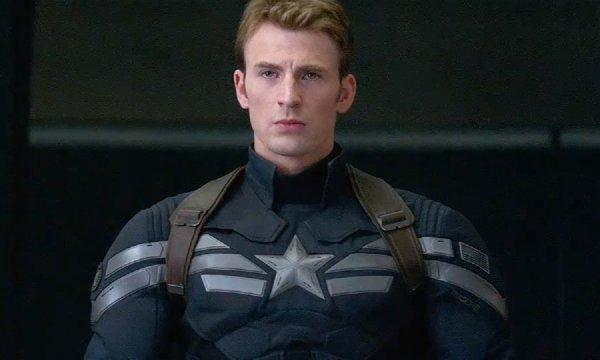
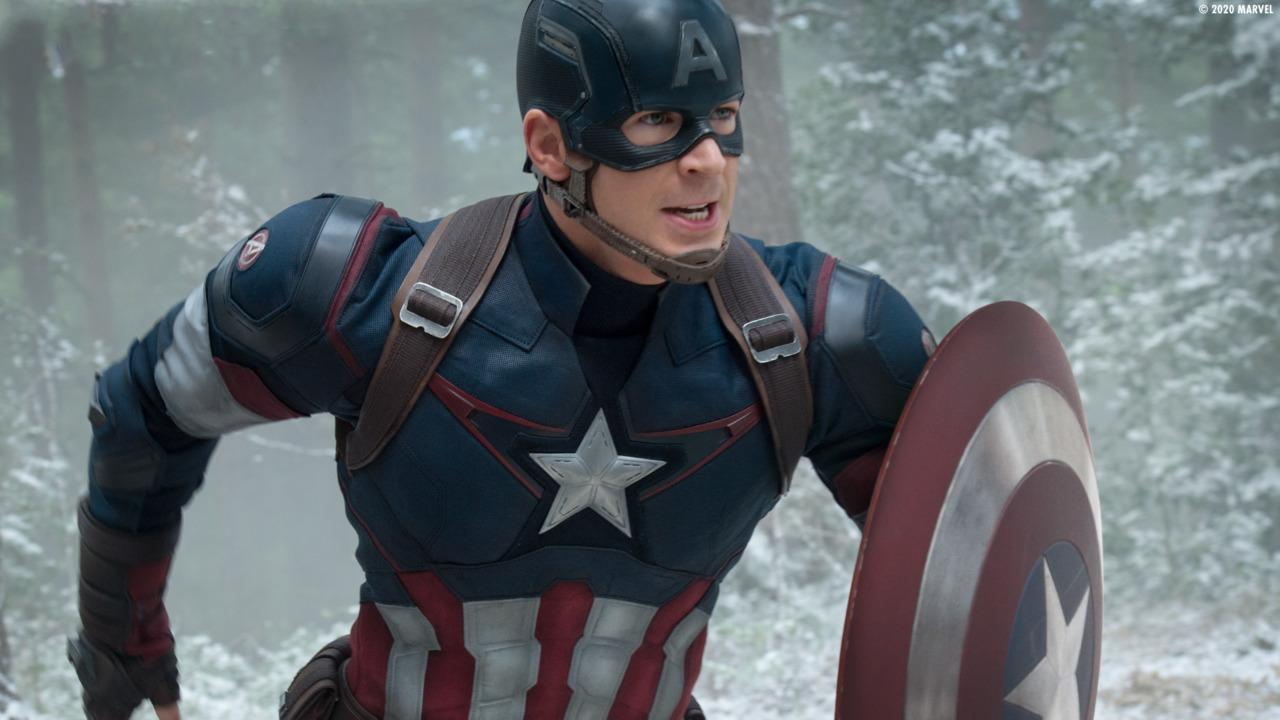
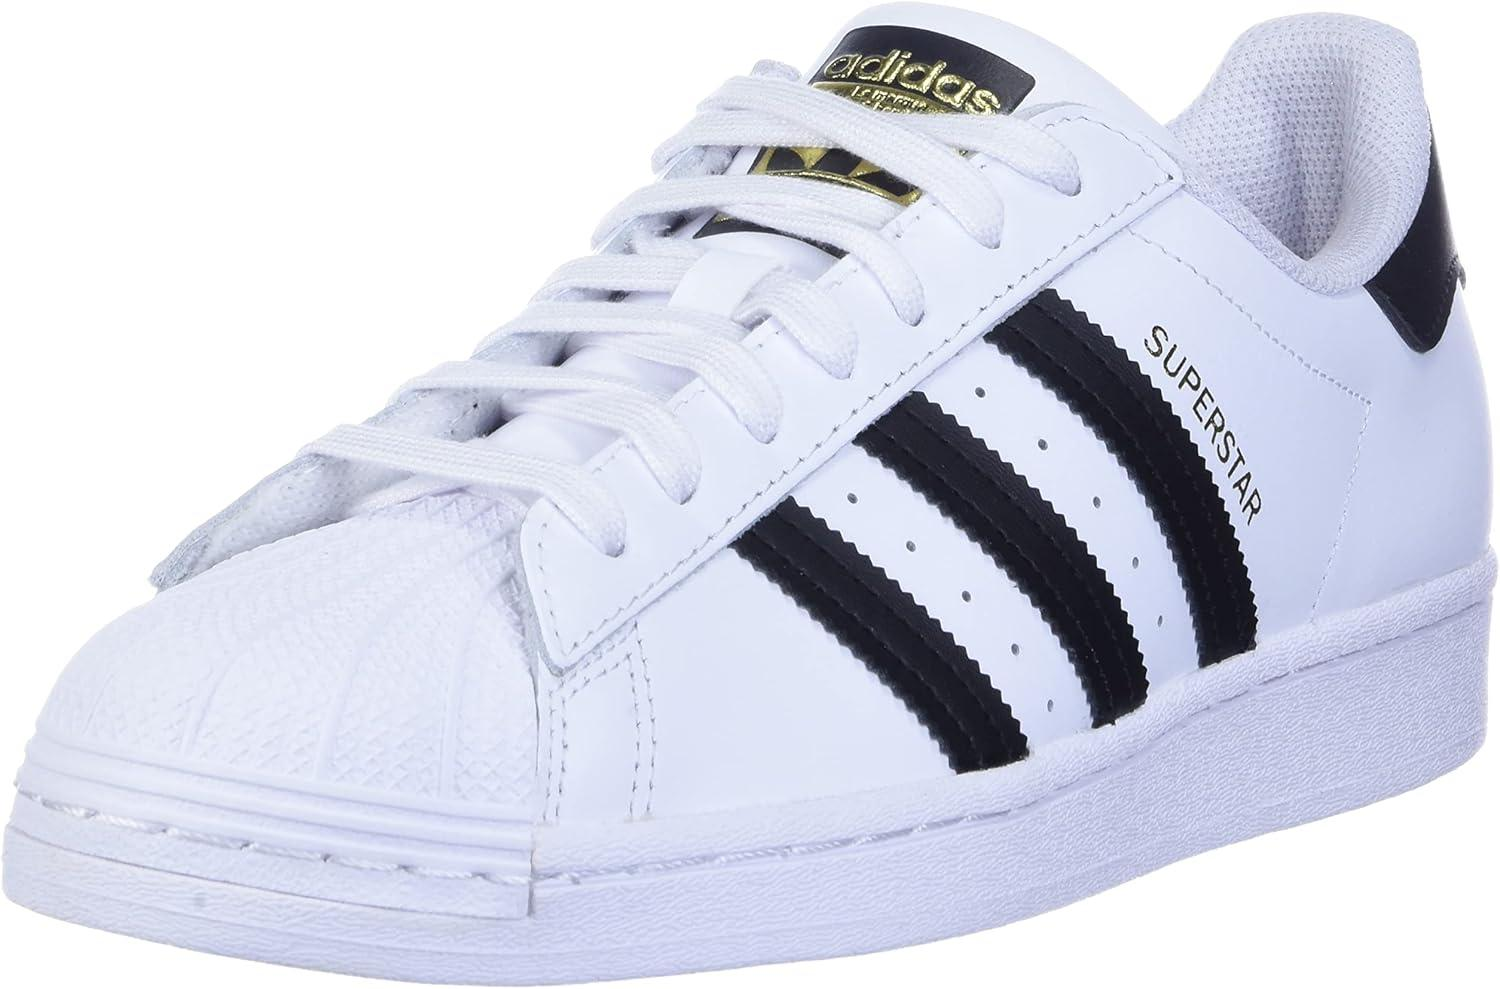
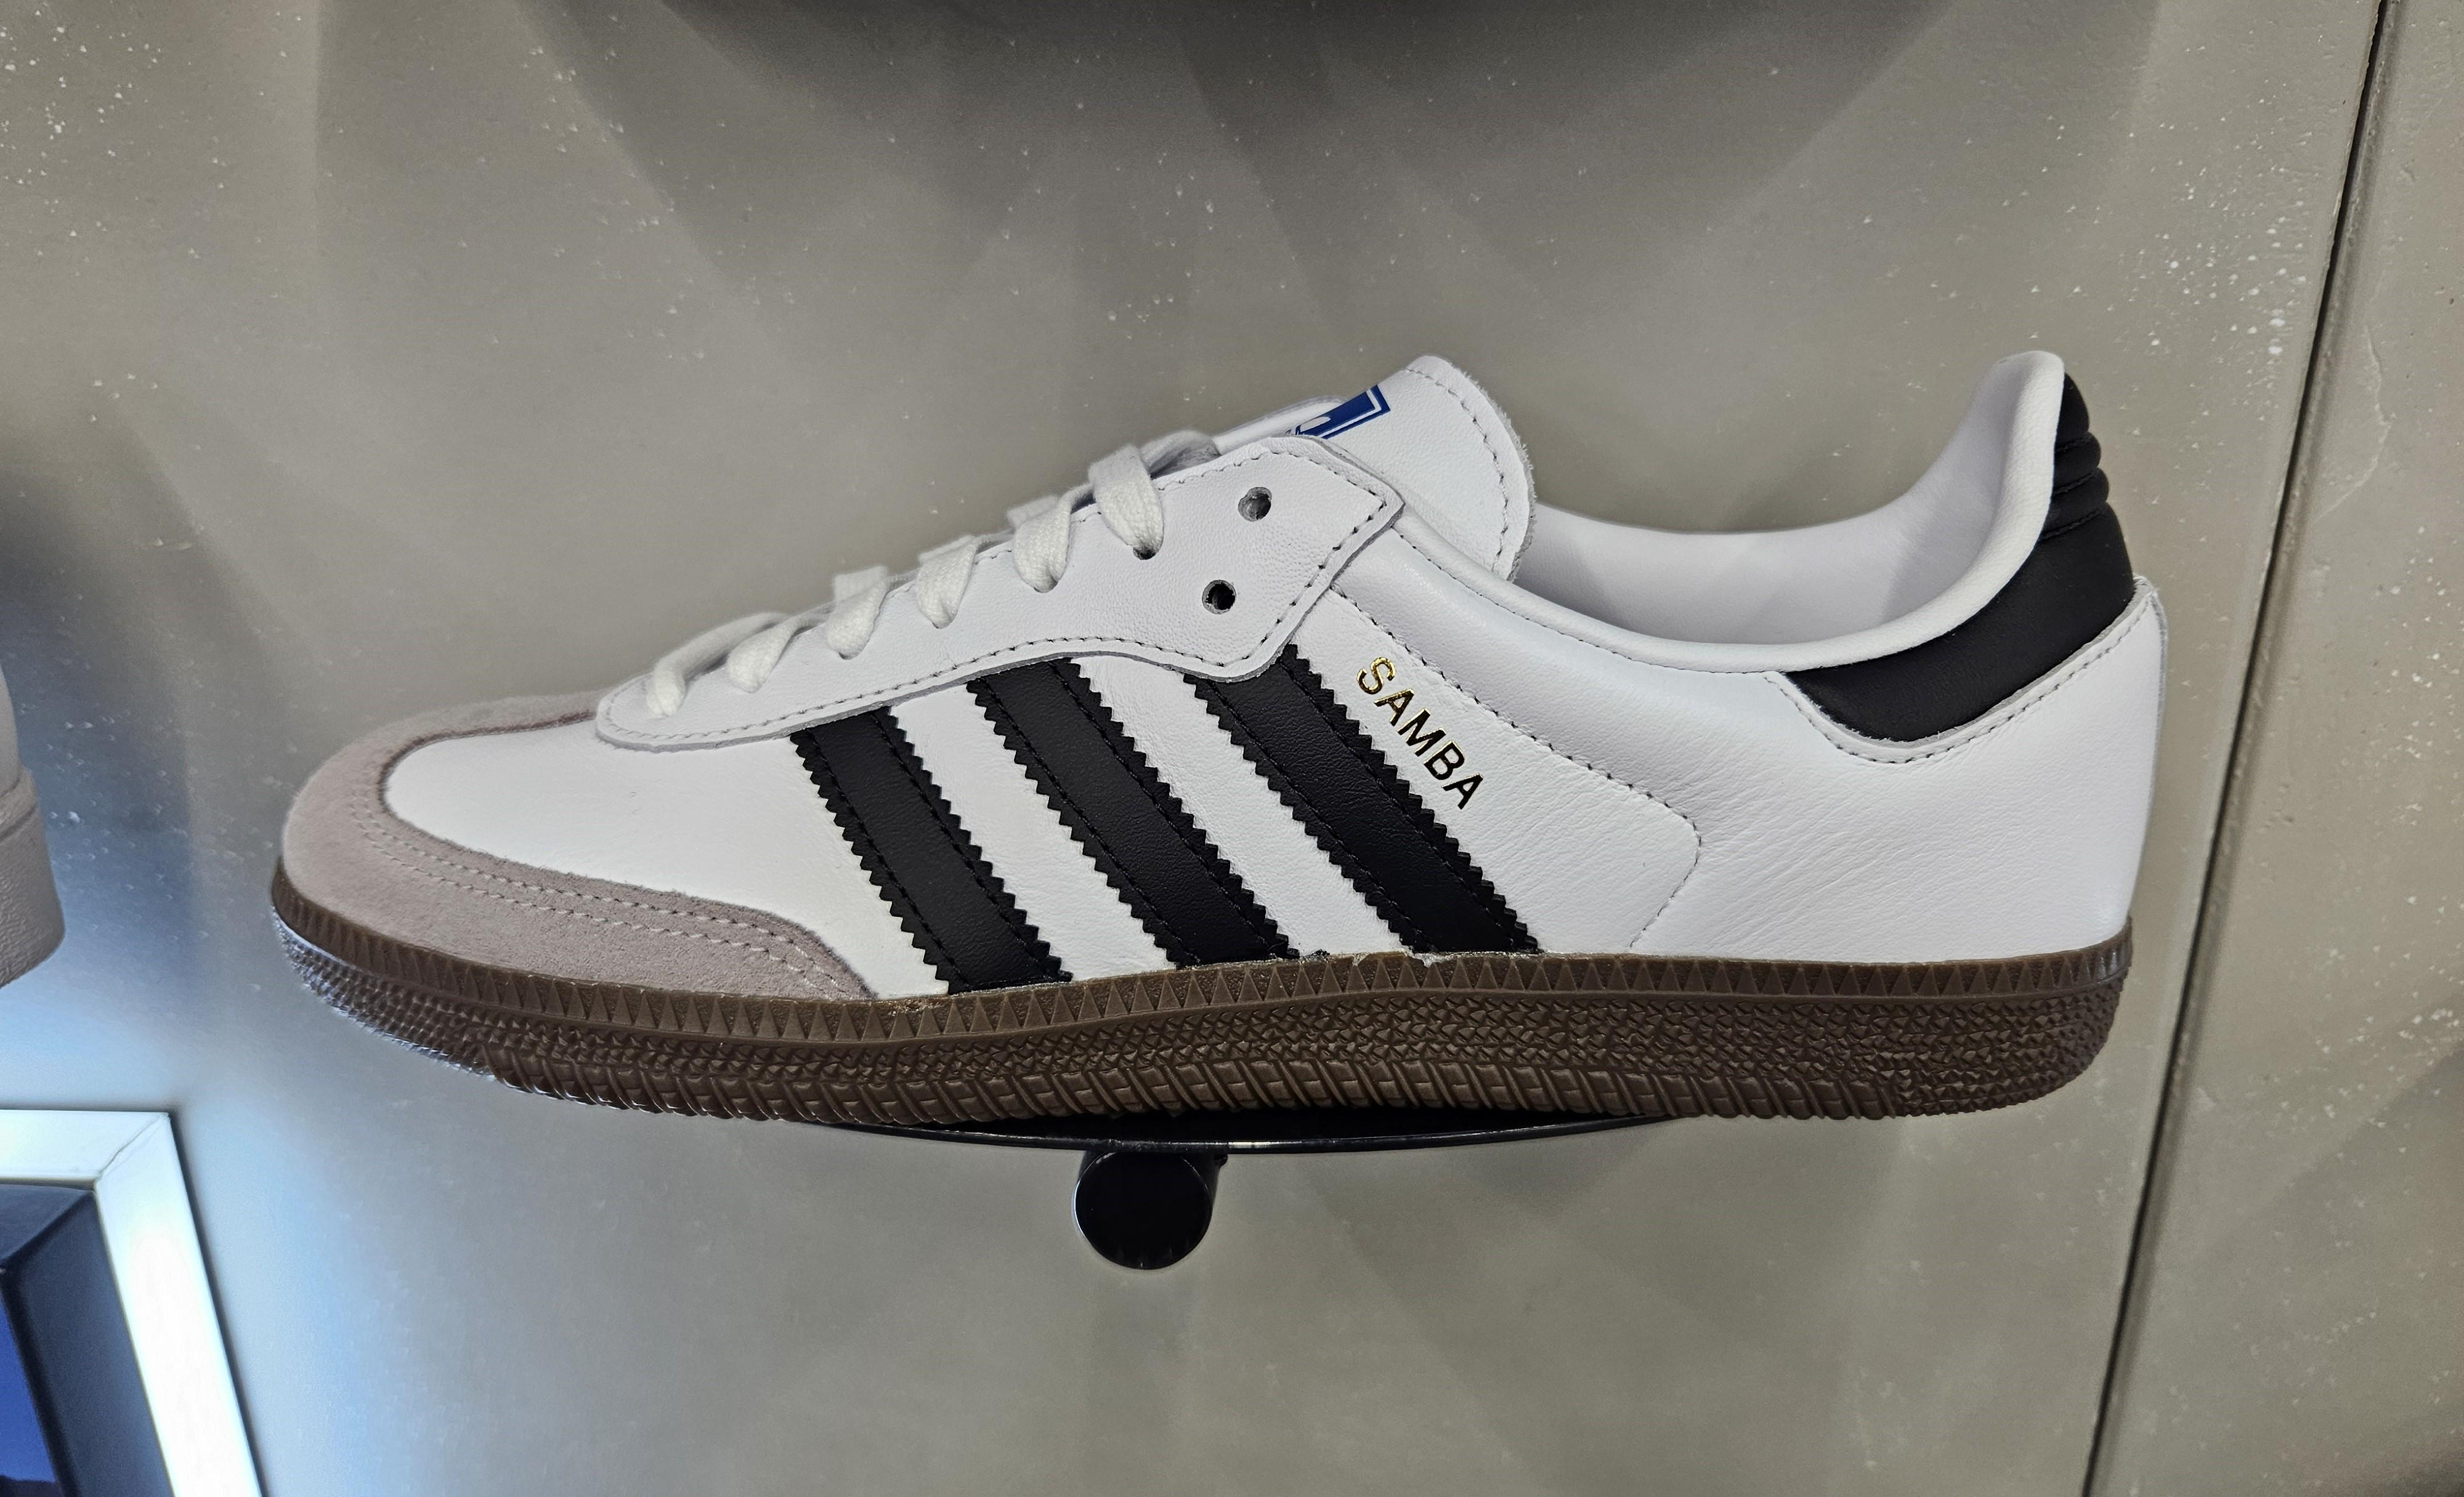
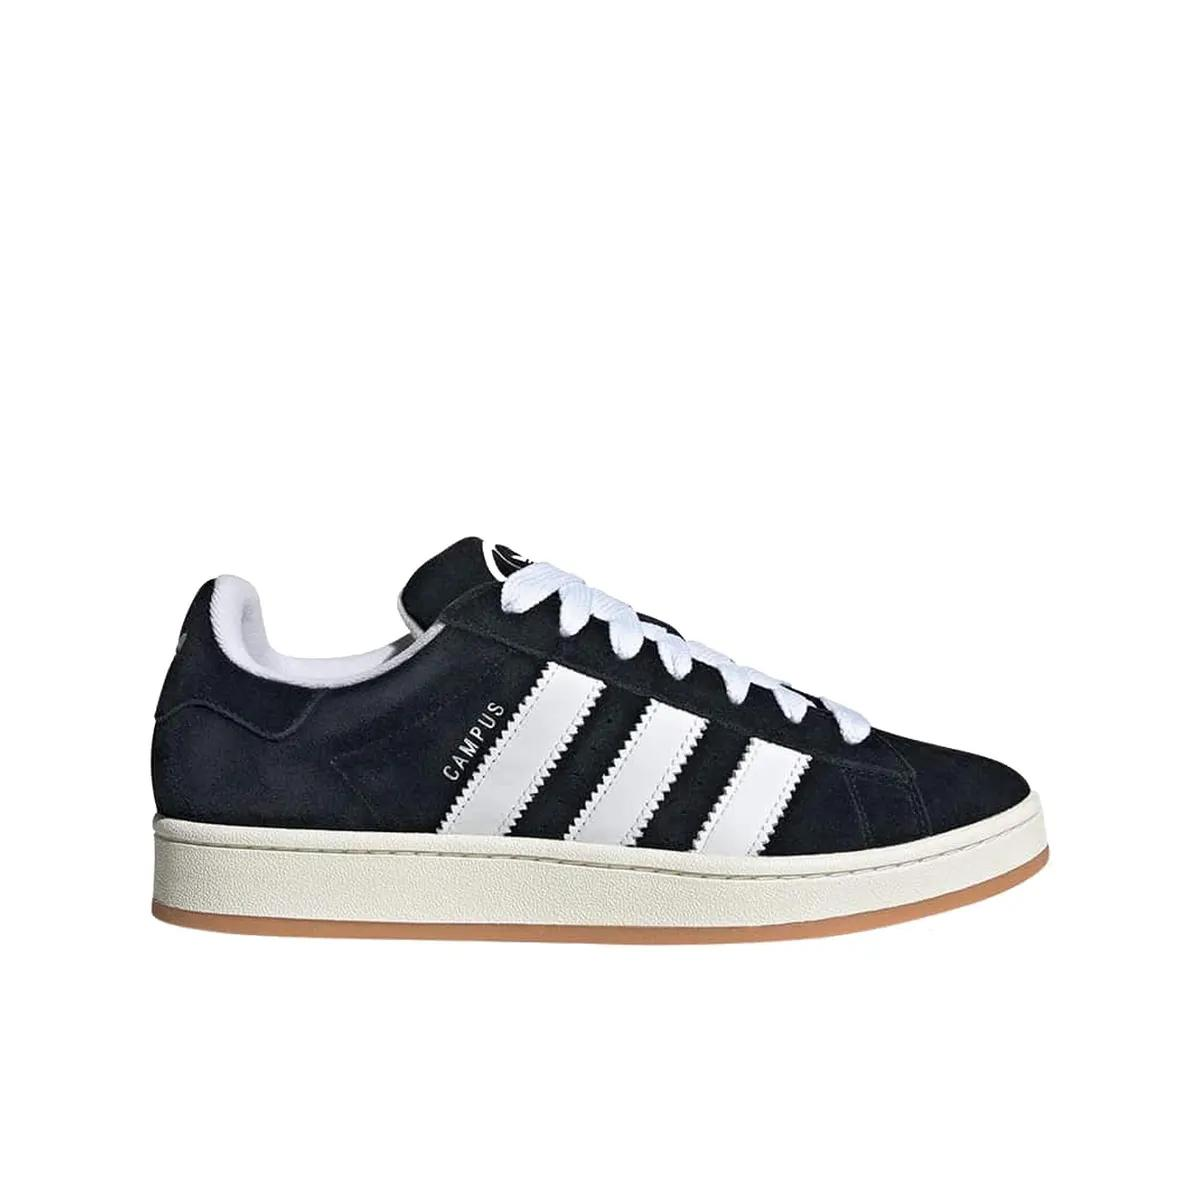
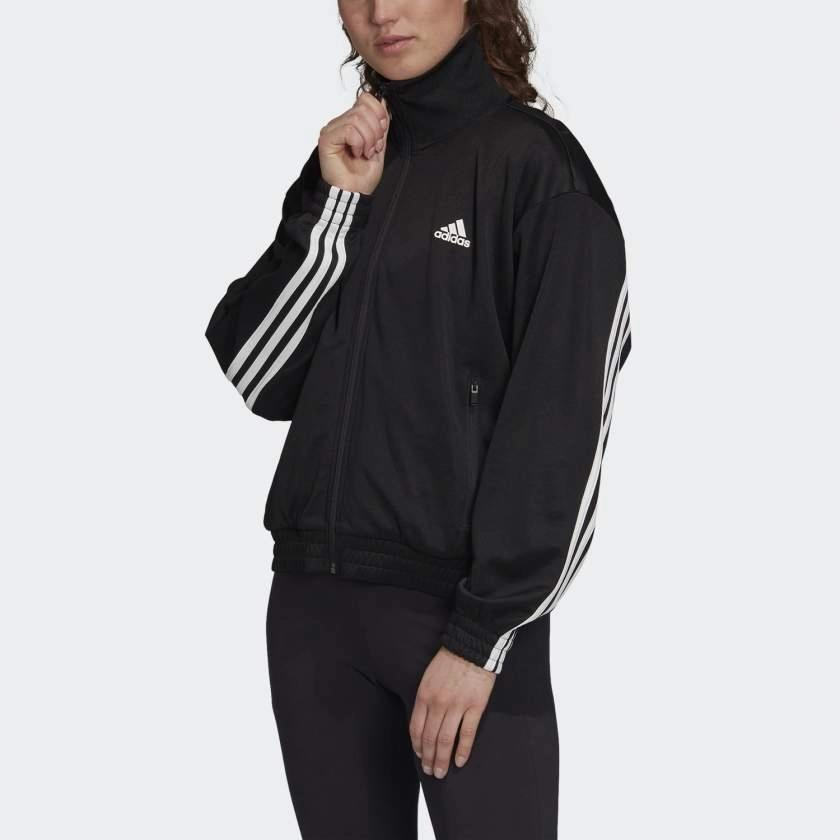
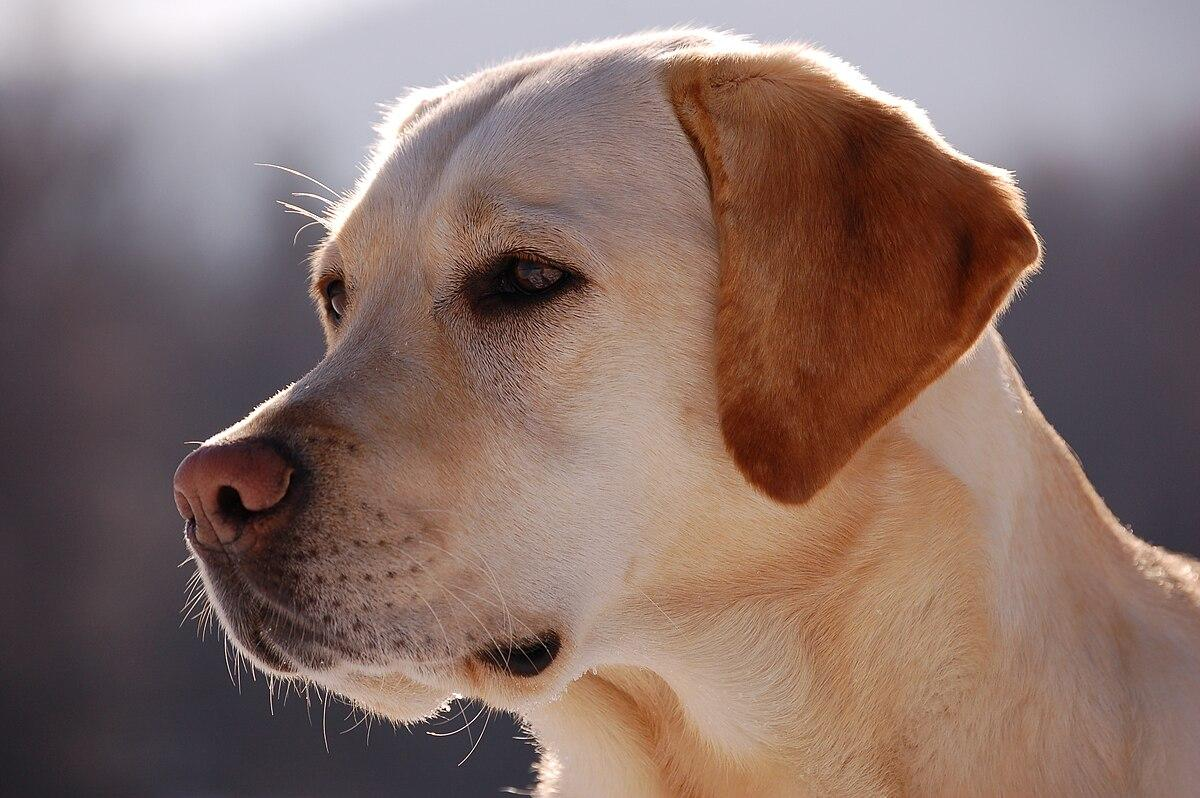
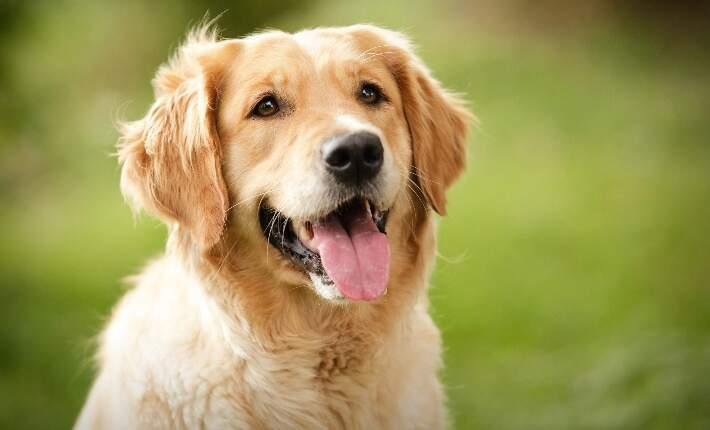
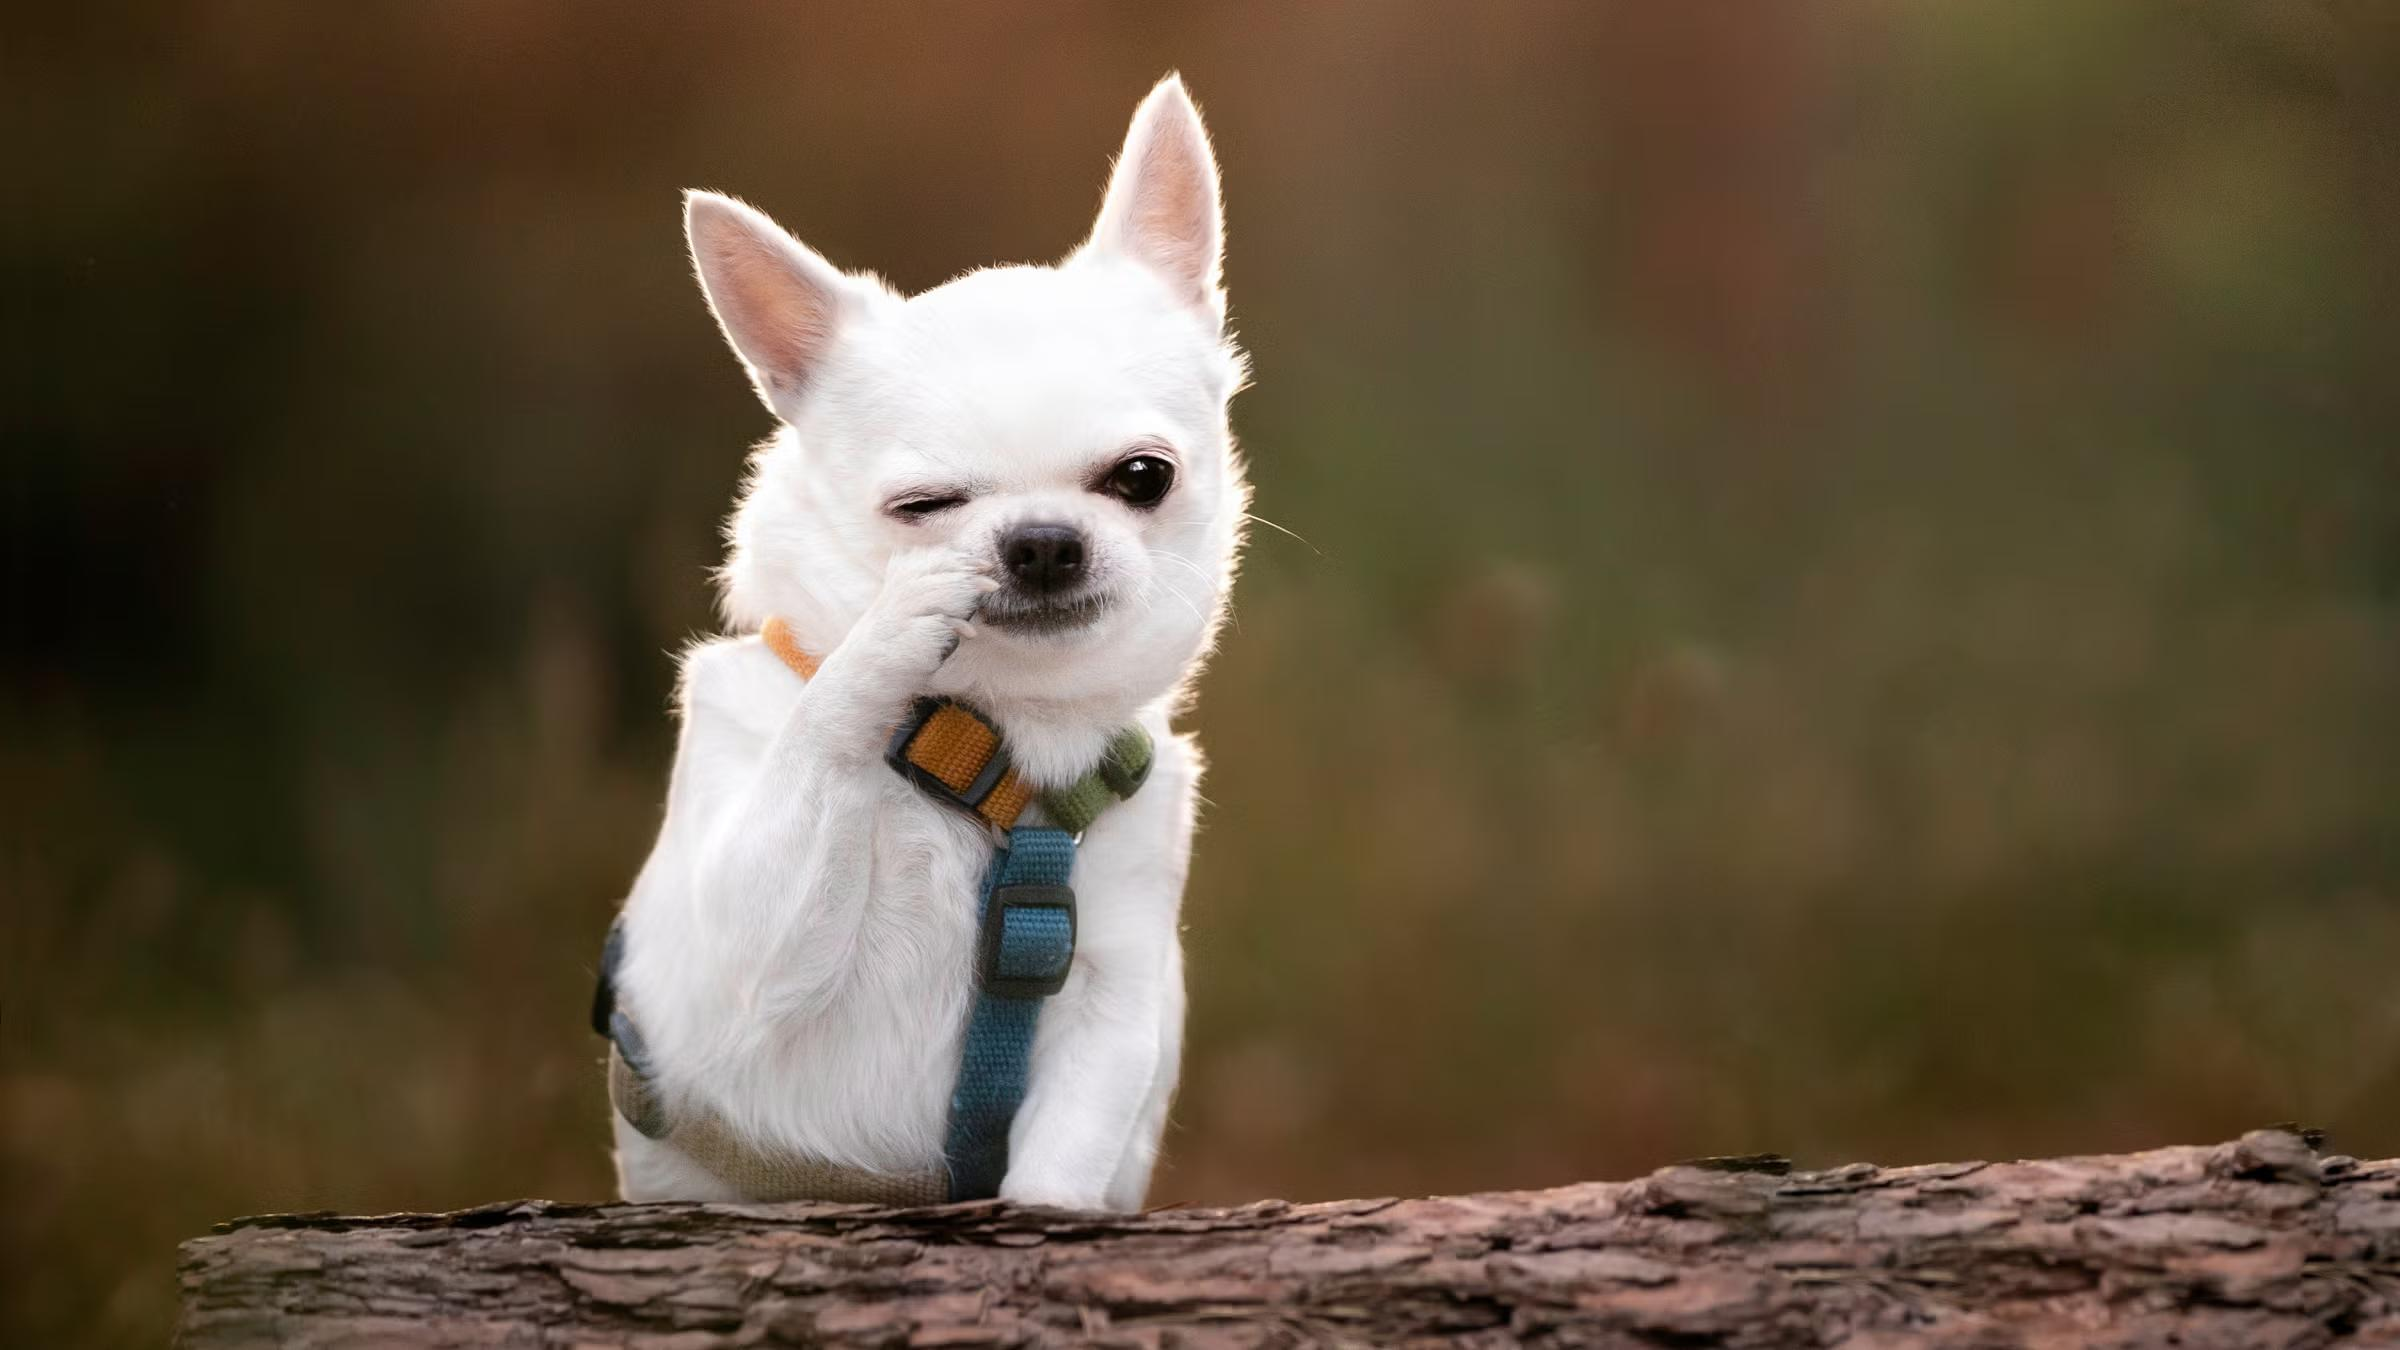
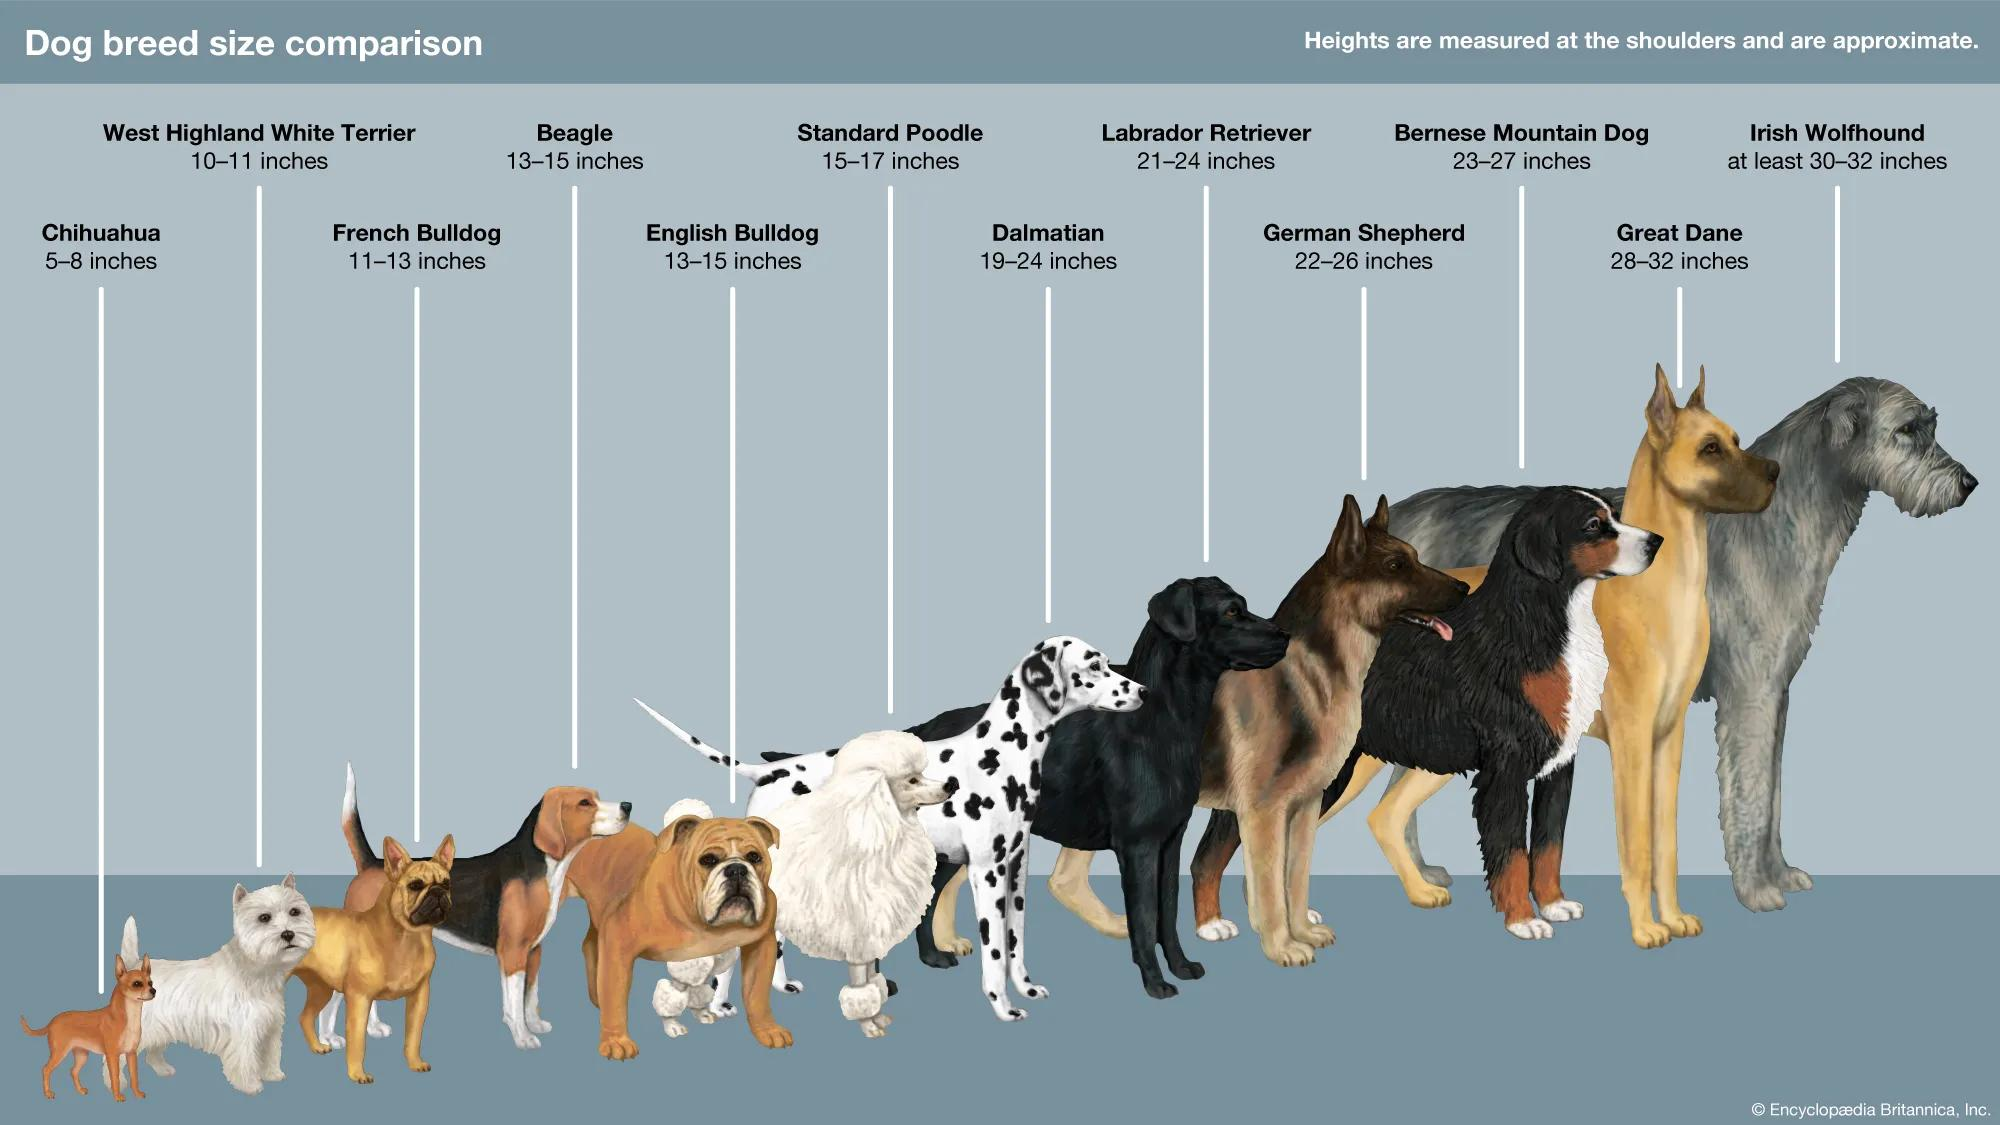
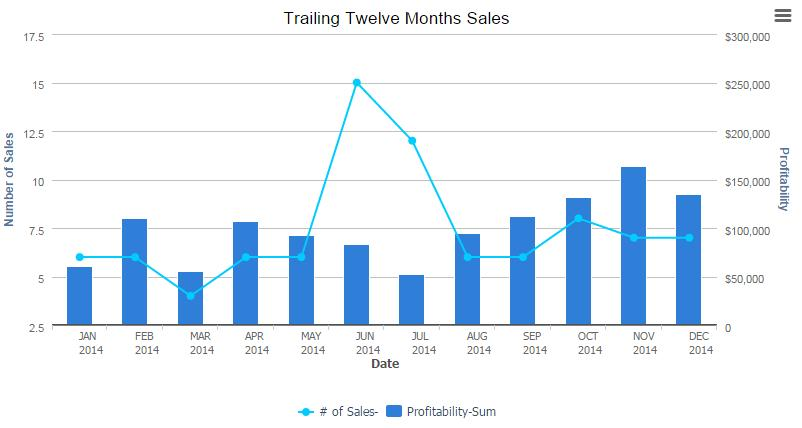
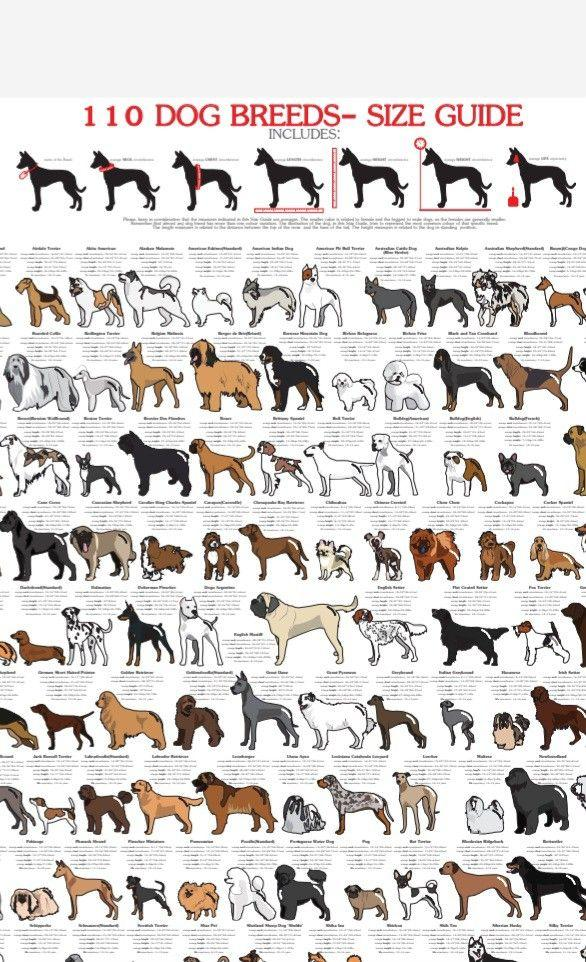
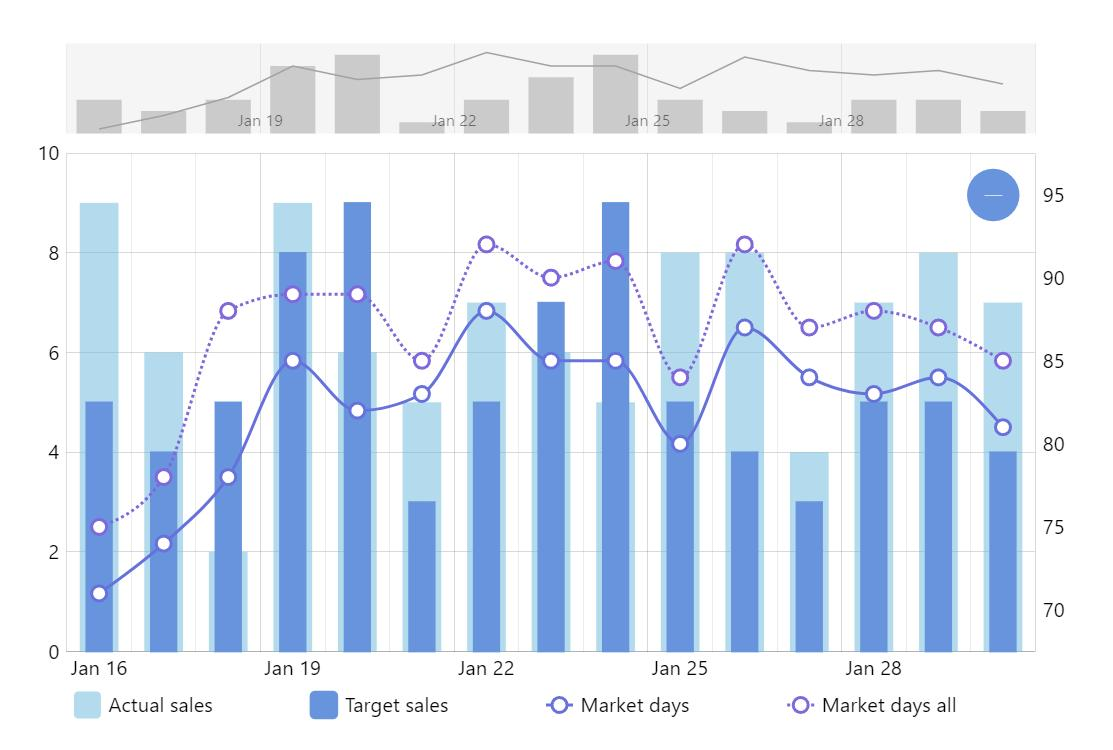
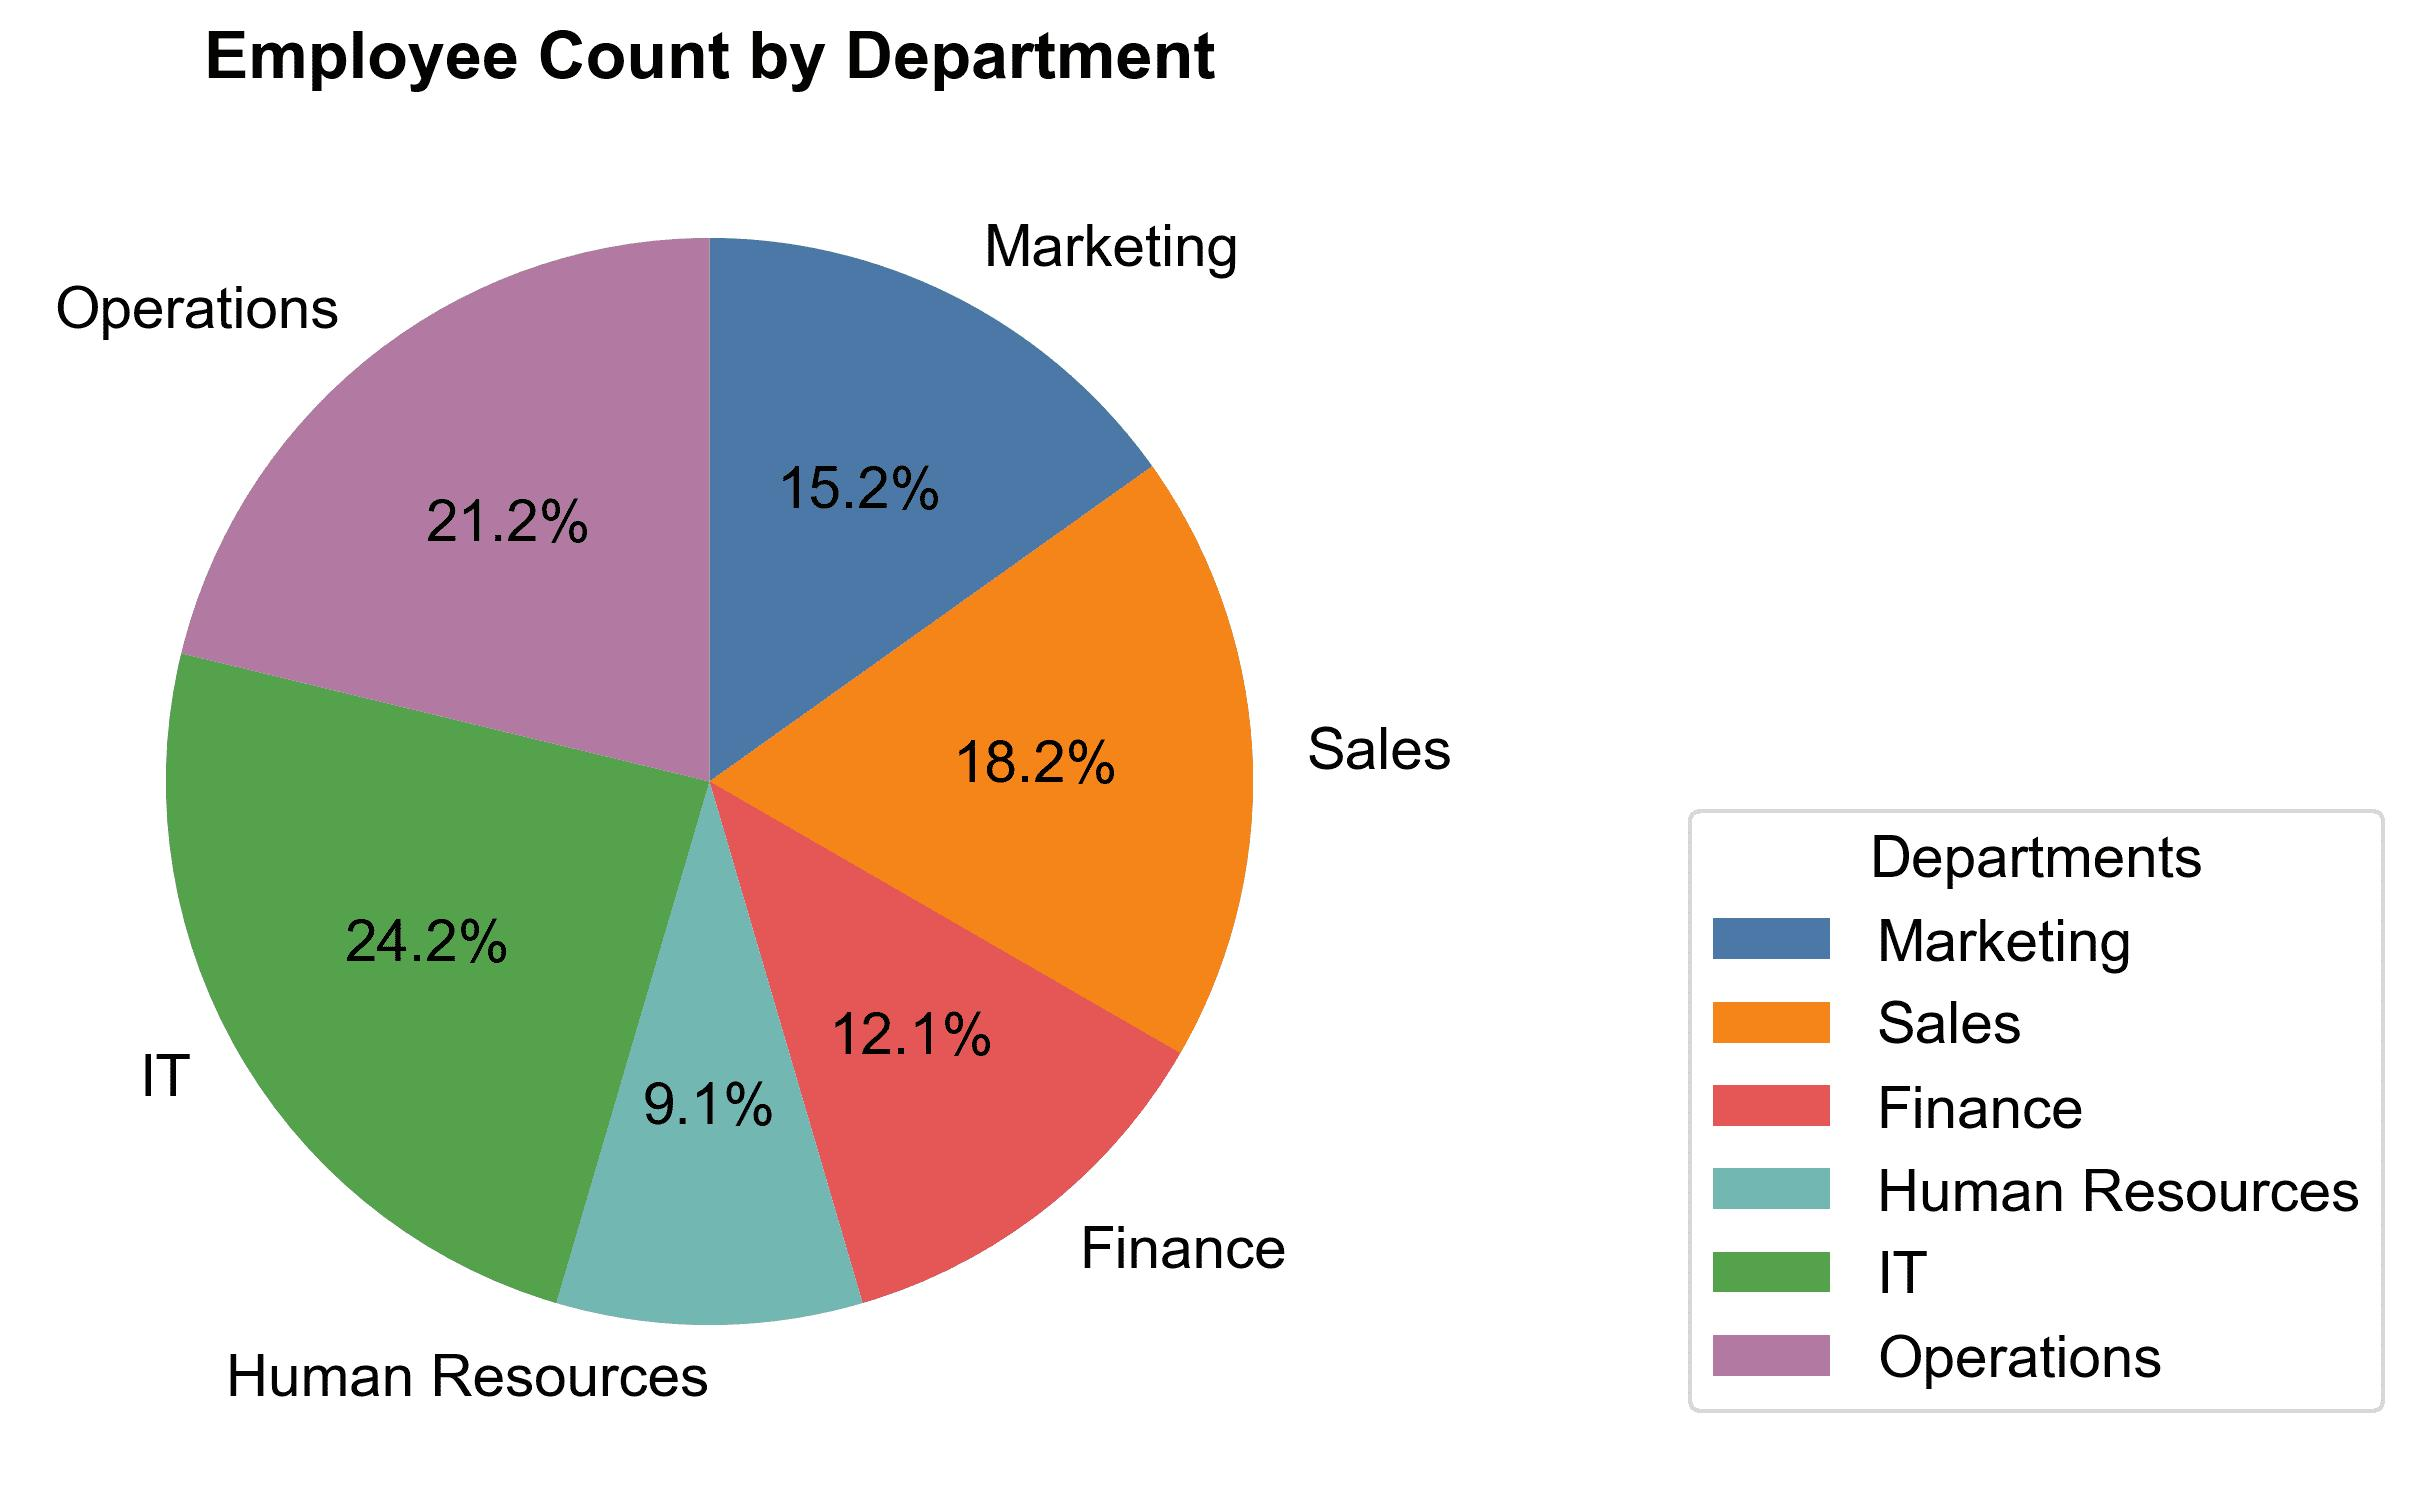
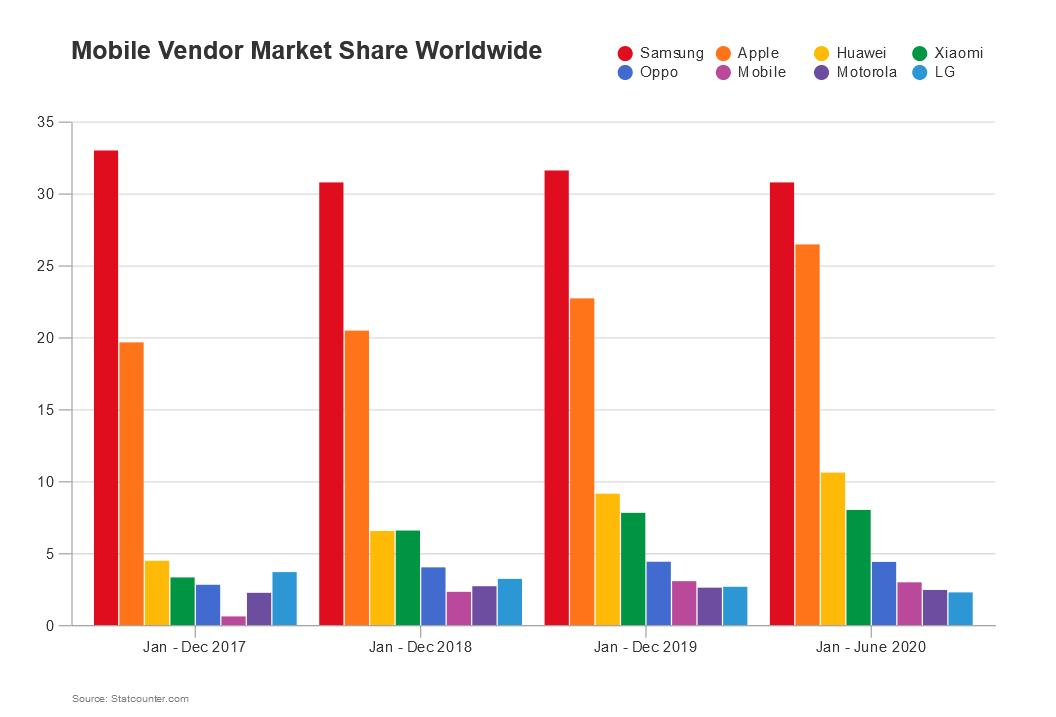
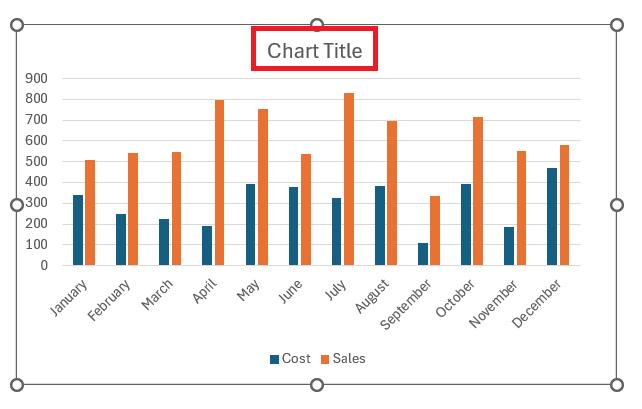
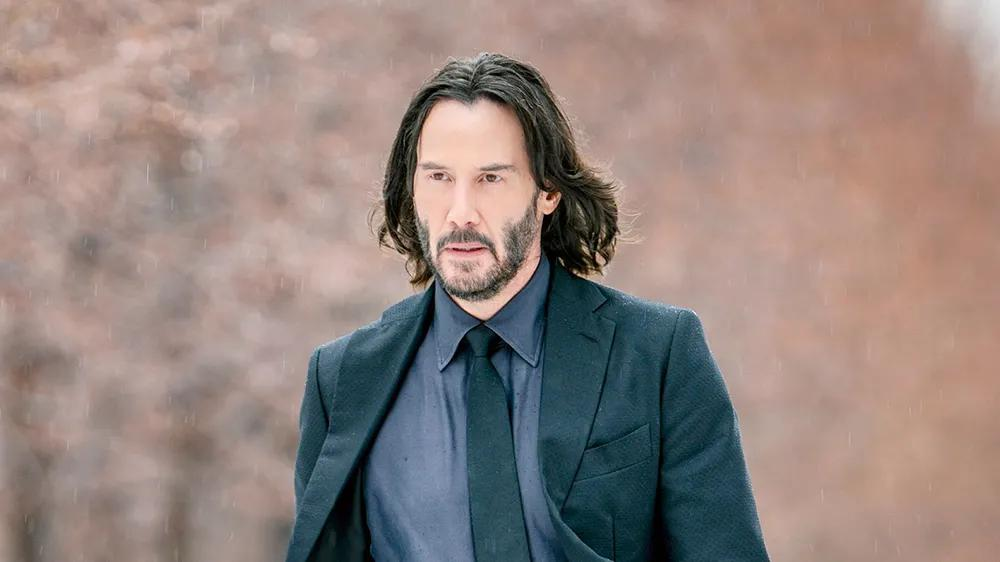
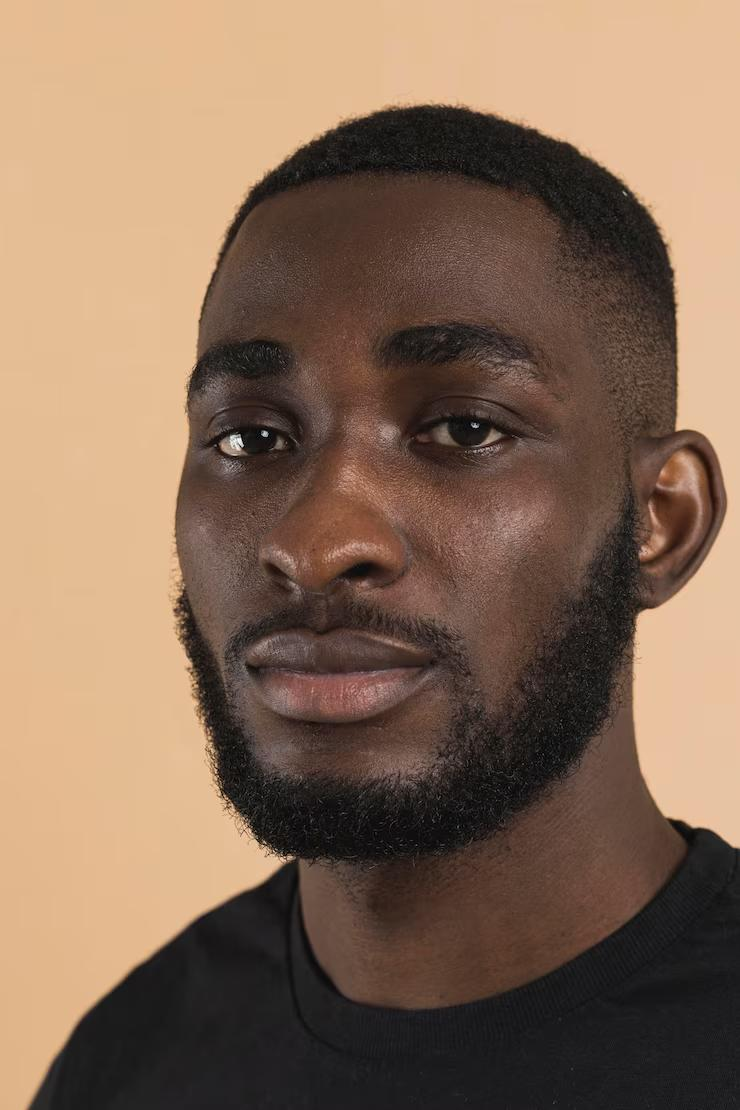
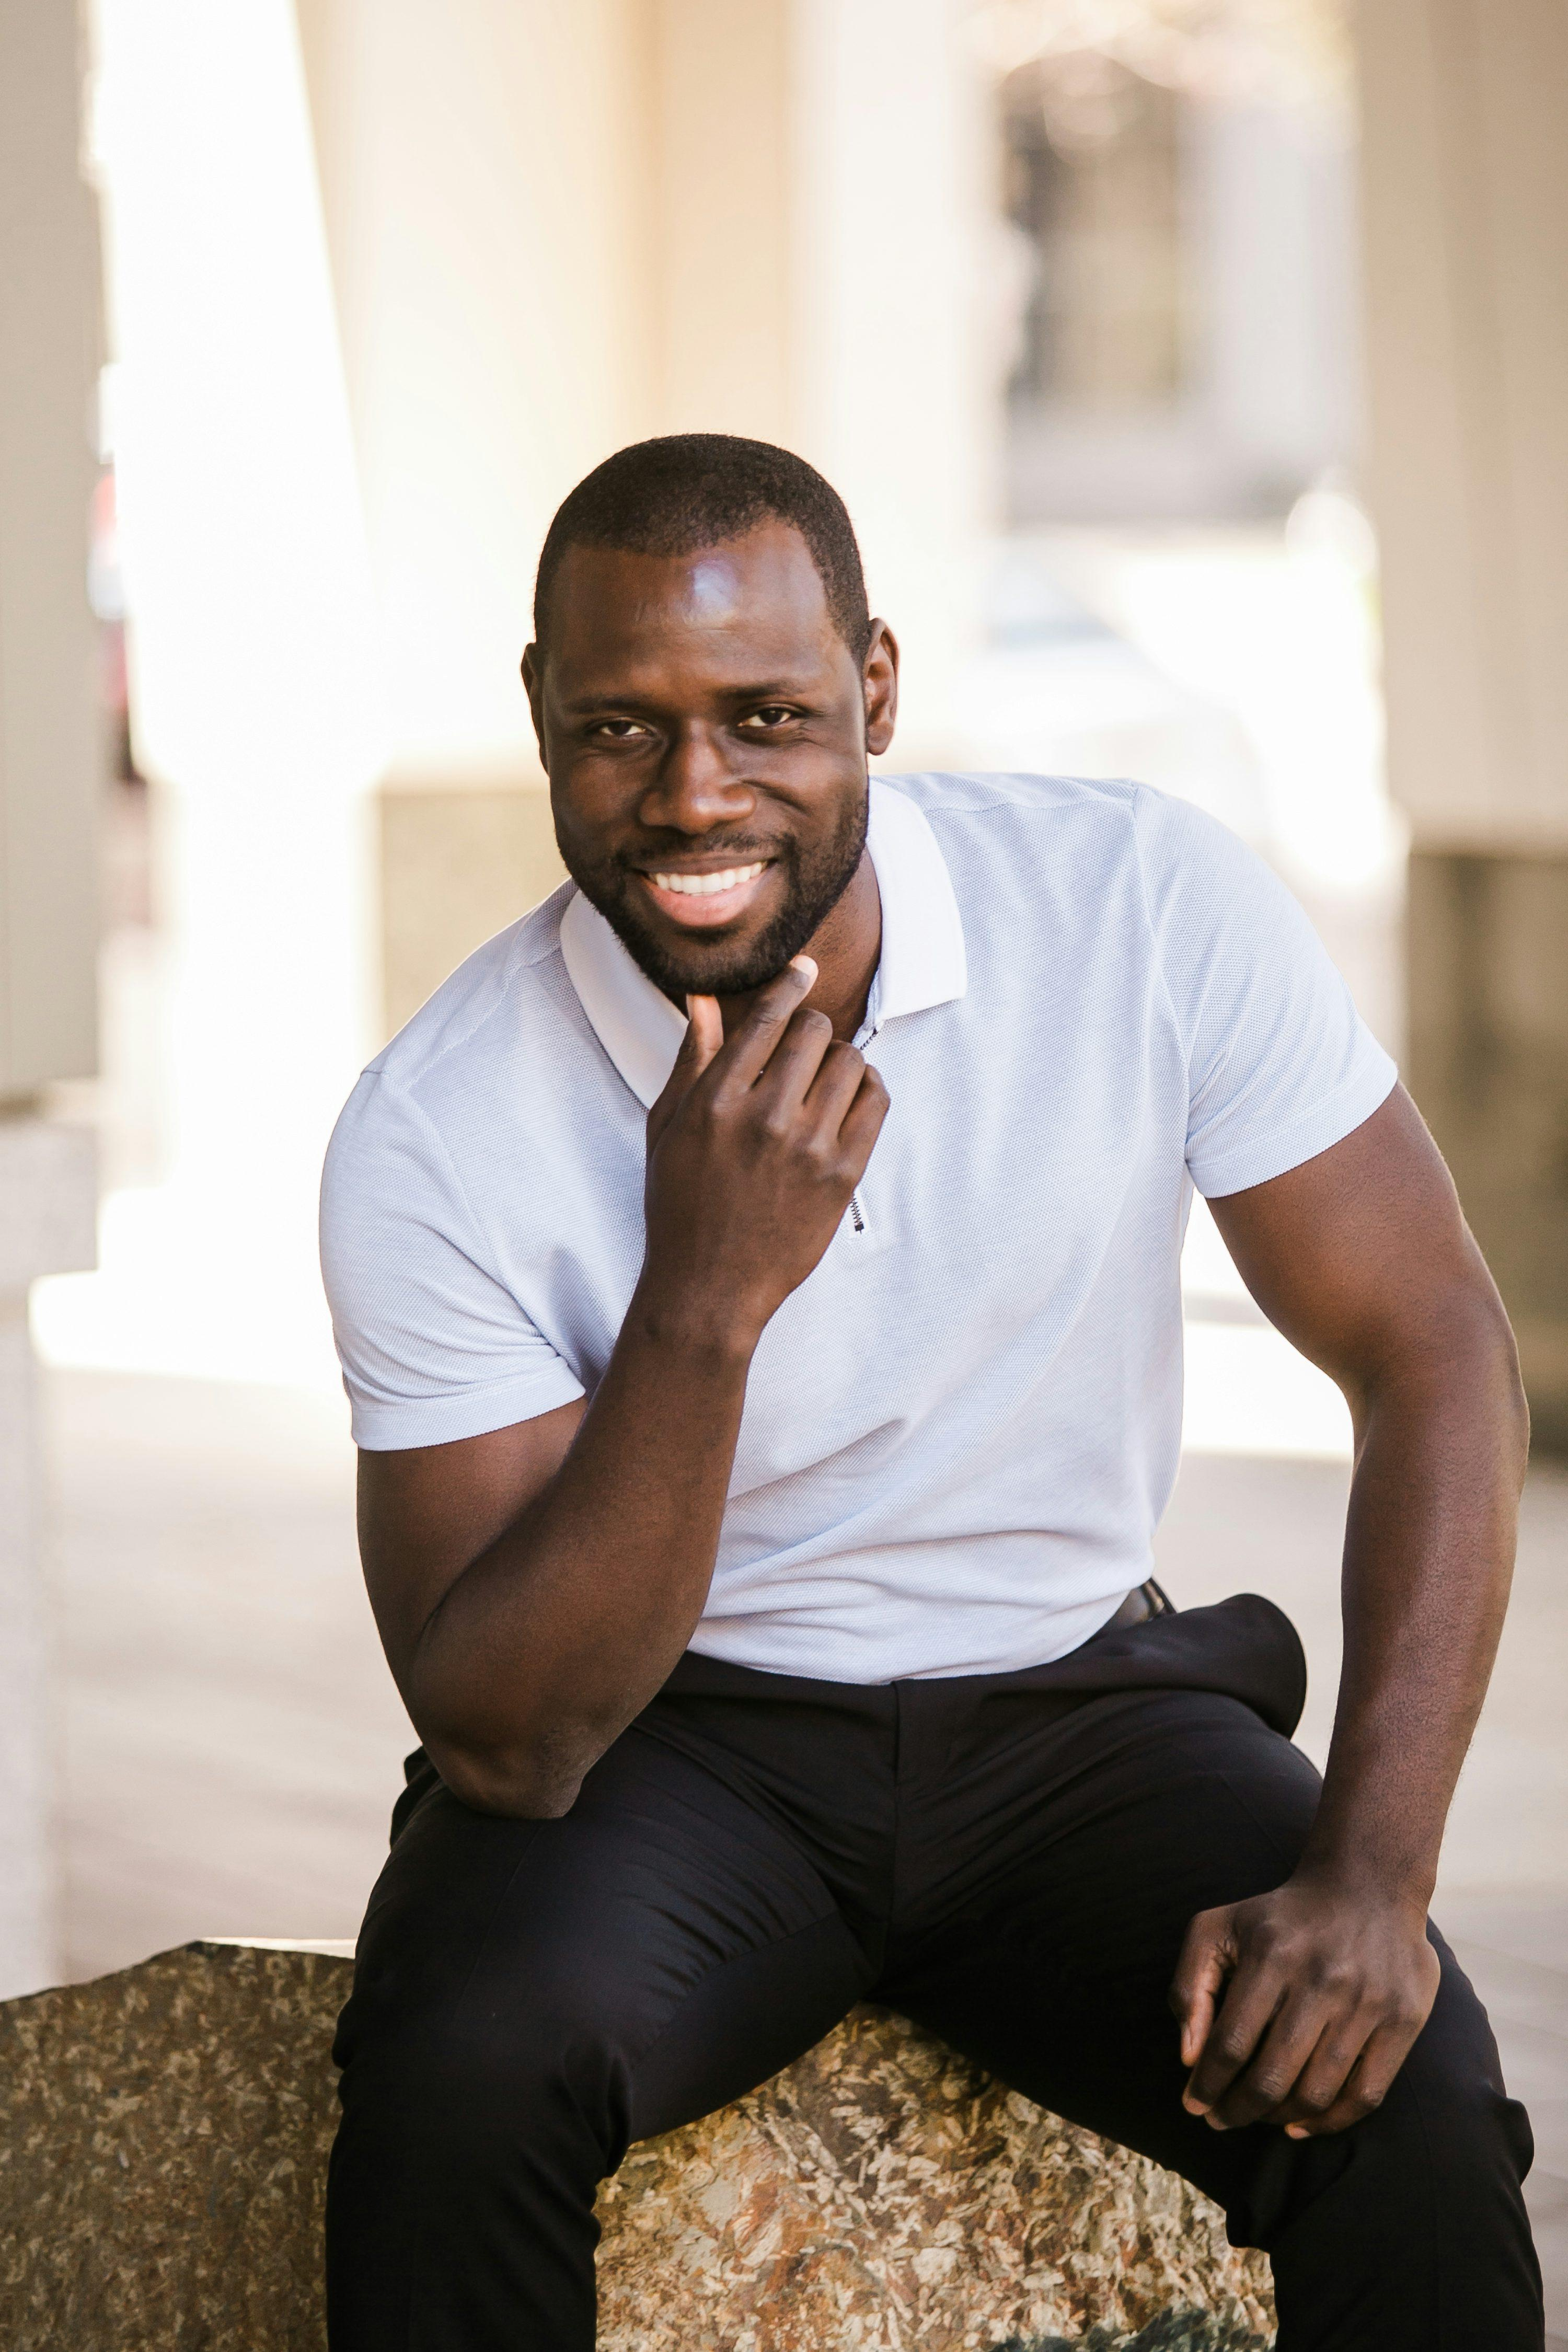
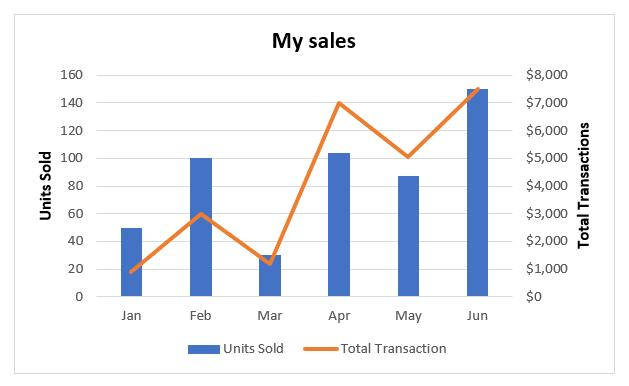
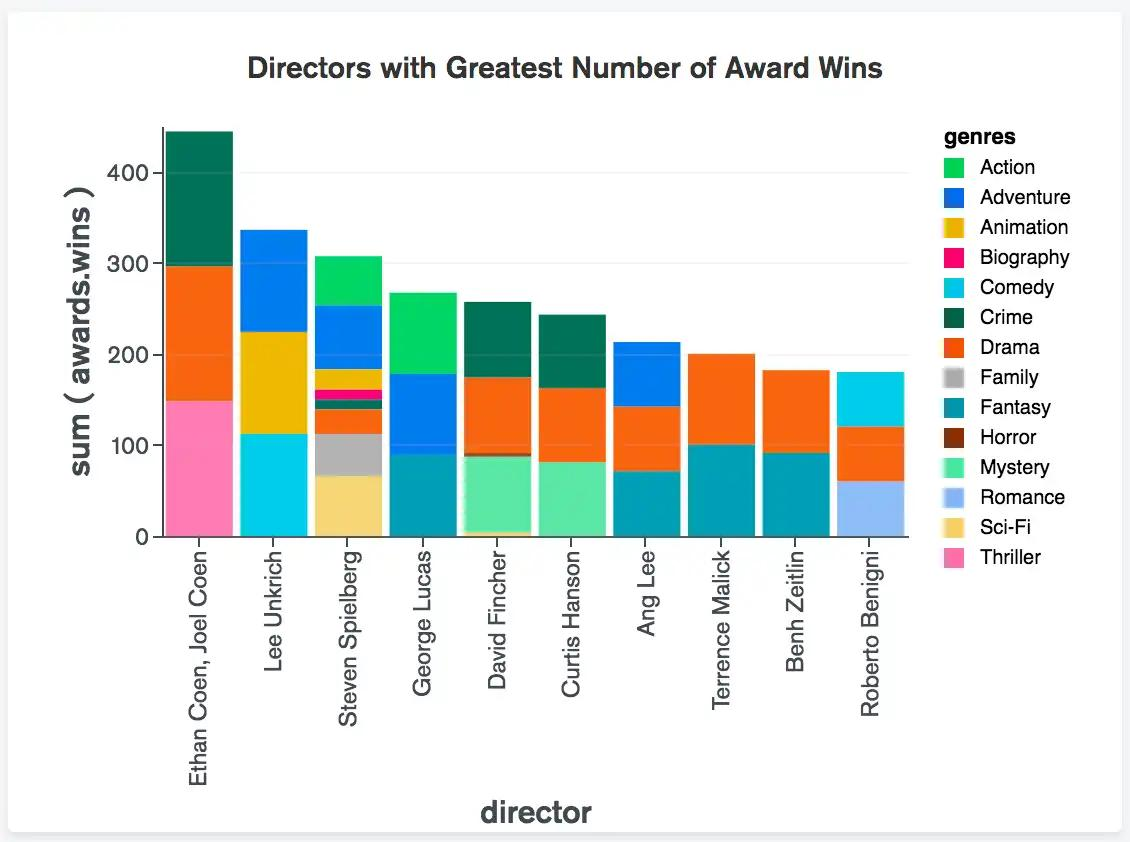

In [11]:
urls_dict = gcp_dict_loaded.values()
show_top_images_from_urls(urls_dict)

In [ ]:
# client.delete_collection(collection_name="summary_image")


True

In [51]:
from langchain.chat_models import init_chat_model
from PIL import Image
import requests
from io import BytesIO
from qdrant_client import QdrantClient
from qdrant_client.http import models as qm
from sentence_transformers import SentenceTransformer
from langchain_core.documents import Document
from langchain_google_vertexai import ChatVertexAI
import time
# Setup Gemini
llm = init_chat_model("google_genai:gemini-2.0-flash-001")

text_encoder = SentenceTransformer("BAAI/bge-base-en")

# client.recreate_collection(
#                 collection_name="summary_image",
#               ectorParams(size=768, distance=Distance.COSINE)
#             )  vectors_config=V


def summarize_and_index_gemini_with_document(image_url, image_id):
    message = {
    "role": "user",
    "content": [
        {
            "type": "text",
            "text": "Please analyze the image in detail. If it is a chart or graph, provide a comprehensive interpretation including the data values, axes, labels, trends, and the overall topic or subject it represents. If the image contains people or landscapes, describe all visible details such as objects, environment, actions, and potential context. Also, try to identify if any person in the image is a well-known or famous individual."
        },
        {"type": "image", "source_type": "url", "url": image_url}
    ],
}
    summary = llm.invoke([message])
    print(f"{image_id} → {summary.content}")
    time.sleep(4)  # Để tránh quá tải API

    # Tạo Document Langchain
    doc = Document(
        page_content=summary.content,
        metadata={
            "image_url": image_url,
            "image_id": image_id
        }
    )

   


    return doc


# Example loop:
documents_content = []
documents_metadata = []
for fname, url in gcp_dict.items():
    doc = summarize_and_index_gemini_with_document(url, image_id=fname)
    documents_content.append(doc.page_content)
    documents_metadata.append(doc.metadata)

client.set_model(embedding_model_name="BAAI/bge-base-en")

client.add(collection_name="summary_image", metadata=documents_metadata, documents=documents_content)


image copy 10.png → Here's a detailed analysis of the image:

**Overall Impression:**

The image is a medium shot of a man in a superhero costume. The lighting is somewhat subdued, creating a serious and perhaps intense mood.

**Detailed Description:**

*   **Person:** The man in the image is actor Chris Evans, dressed as the Marvel Comics character Captain America.
*   **Costume:** He is wearing a dark blue suit with silver accents. A large silver star is prominently displayed on the chest. He has brown straps crisscrossing his chest. The design of the suit suggests a more tactical or stealth-focused version of Captain America's uniform.
*   **Expression:** Evans has a neutral to slightly stern expression. He is looking directly at the viewer.
*   **Background:** The background is dark and out of focus, appearing to be an interior space. It is mostly dark gray.

**Contextual Interpretation:**

*   Given the presence of Chris Evans in a Captain America costume, the image is almost cert

['32ce7e1ebc804837ab0bfbf93b1df733',
 '3c84b022696f447e930108977abb1eef',
 'c47789c51da2446ba6c1727e3f6ba7ae',
 'd2a2e479b2114bbeb70a80ddbe5085fa',
 '94d3f9d1c9e949d7bdac3a71bac64e18',
 '2378897818bf4661802a48f6ef009e14',
 'd3b4a843675f4289bec9c9f9a4003d79',
 'fe091ae1ad5f412a81a92a14ad4627a0',
 '1ad0e2ce37ce4da3a605ba15214510af',
 '5bdec30d86be4194bbbb8223ca03b6d0',
 'ad224c5f678d4d898b759930468fdba9',
 'c849ac33db834c72aa813f575a39542d',
 '50afab32ba3f443089b4e887e0f3dd88',
 '3966fe2a5bc54d53b20207dd83707e96',
 '279566a5398c46ed8f6623ed537f05a6',
 '2435b1c0471c4fb29ec7985eeb991af5',
 '03cde6ec13334679a3990994753b8cdd',
 'b872b7883acf46aeb7a0be5476f0871b',
 '4331e7a531914018a7bda9df573914b1',
 '268ade95ffb646b1b190eaa7a62af4d9',
 '50892810896a497280c51a913de9533f']

1min 39s

In [45]:
documents_metadata

[{'image_url': 'https://storage.googleapis.com/kyanon-retrieval/image%20copy%2010.png',
  'image_id': 'image copy 10.png'},
 {'image_url': 'https://storage.googleapis.com/kyanon-retrieval/image%20copy%2011.png',
  'image_id': 'image copy 11.png'},
 {'image_url': 'https://storage.googleapis.com/kyanon-retrieval/image%20copy%2012.png',
  'image_id': 'image copy 12.png'},
 {'image_url': 'https://storage.googleapis.com/kyanon-retrieval/image%20copy%2013.png',
  'image_id': 'image copy 13.png'},
 {'image_url': 'https://storage.googleapis.com/kyanon-retrieval/image%20copy%2014.png',
  'image_id': 'image copy 14.png'},
 {'image_url': 'https://storage.googleapis.com/kyanon-retrieval/image%20copy%2015.png',
  'image_id': 'image copy 15.png'},
 {'image_url': 'https://storage.googleapis.com/kyanon-retrieval/image%20copy%2016.png',
  'image_id': 'image copy 16.png'},
 {'image_url': 'https://storage.googleapis.com/kyanon-retrieval/image%20copy%2017.png',
  'image_id': 'image copy 17.png'},
 {'image

In [46]:
documents_content

['The image shows a close-up of Chris Evans dressed as Captain America. He is wearing a dark blue and gray suit with a large silver star on the chest. The suit also has brown straps crossing over his shoulders. He has a serious expression on his face. The background is dark and out of focus, suggesting an indoor setting.',
 'The image shows the character Captain America, played by Chris Evans, in what appears to be a scene from a movie or TV show. He is wearing his iconic Captain America suit, which is primarily blue with red and white accents, including a white star on the chest. He also has his helmet on, which has the letter "A" on the forehead. He\'s holding his shield, which has a red, white, and blue concentric circle design with a white star in the center.\n\nThe background appears to be a snowy or wintery forest scene, with bare trees and a slightly blurred effect, suggesting motion. Captain America has a determined expression on his face, and his posture suggests that he is ru

In [ ]:
# client.delete_collection(collection_name="embedding_image")
# # 

True

In [71]:


# Collection 2: embedding_image (image embedding từ CLIP)
client.recreate_collection(
                collection_name="embedding_image",
                vectors_config={"image": VectorParams(size=1024, distance=Distance.COSINE)}
            )

C:\Users\Admin\AppData\Local\Temp\ipykernel_13468\557035233.py:2: DeprecationWarning: `recreate_collection` method is deprecated and will be removed in the future. Use `collection_exists` to check collection existence and `create_collection` instead.
  client.recreate_collection(


True

In [74]:
import time
from qdrant_client.http.models import PointStruct
import uuid

def embed_and_index_as_document(image_url, image_id):
    # Load image
    response = requests.get(image_url)
    img = Image.open(BytesIO(response.content)).convert("RGB")

    # Embed image
    time_start = time.time()
    inputs = processor(images=img, return_tensors="pt").to("cuda")
    with torch.no_grad():
        embeddings = vlmmodel.get_image_features(**inputs)
        embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=-1)

    # Tạo Document chuẩn LangChain
    doc = Document(
        page_content="Image representation using VLM2Vec-V2.0",  # Có thể thay bằng caption sau này
        metadata={
            "image_url": image_url,
            "image_id": image_id
        }
    )
    print(f"Embedding {image_id} → {embeddings.shape}")
    unique_id = str(uuid.uuid4())

    # Index vào Qdrant
    client.upsert(
    collection_name="embedding_image",
        points=[
            PointStruct(
                id=unique_id,
                vector={"image": embeddings}, 
                payload={
                    "image_url": doc.metadata["image_url"],
                    "image_id": doc.metadata["image_id"],
                    "page_content": doc.page_content,
                }
            )
        ]
    )
    time_end = time.time()
    print(f"Indexed {image_id} in {time_end - time_start:.2f} seconds")
    return doc

In [75]:
for fname, url in gcp_dict.items():
    doc = embed_and_index_as_document(image_url=url, image_id=fname)

Embedding image copy 10.png → torch.Size([1, 1024])
Indexed image copy 10.png in 11.00 seconds
Embedding image copy 11.png → torch.Size([1, 1024])
Indexed image copy 11.png in 10.61 seconds
Embedding image copy 12.png → torch.Size([1, 1024])
Indexed image copy 12.png in 8.83 seconds
Embedding image copy 13.png → torch.Size([1, 1024])
Indexed image copy 13.png in 8.76 seconds
Embedding image copy 14.png → torch.Size([1, 1024])
Indexed image copy 14.png in 8.43 seconds
Embedding image copy 15.png → torch.Size([1, 1024])
Indexed image copy 15.png in 8.62 seconds
Embedding image copy 16.png → torch.Size([1, 1024])
Indexed image copy 16.png in 8.44 seconds
Embedding image copy 17.png → torch.Size([1, 1024])
Indexed image copy 17.png in 8.71 seconds
Embedding image copy 18.png → torch.Size([1, 1024])
Indexed image copy 18.png in 8.40 seconds
Embedding image copy 19.png → torch.Size([1, 1024])
Indexed image copy 19.png in 8.44 seconds
Embedding image copy 2.png → torch.Size([1, 1024])
Indexed

4min55s

In [103]:
from langchain.vectorstores import Qdrant
from qdrant_client.http.models import NamedVector


def get_documents(query: str, mode: str = "summary", top_k: int = 5) -> list[str]:
    """
    Truy vấn ảnh tương đồng với câu hỏi người dùng (văn bản), và trả về danh sách URL ảnh.

    mode:
        - "summary": so khớp với caption
        - "vlm": so khớp trực tiếp với vector ảnh (cross-modal)

    Returns:
        list[str]: danh sách image_url
    """
    if mode == "summary":
        results = client.query(
            collection_name='summary_image',
            query_text=query,
            limit=top_k,
        )

        
        return [doc.metadata.get("image_url") for doc in results]

    elif mode == "vlm":
        # Nhúng query thành vector bằng VLM
        inputs = processor(text=query, return_tensors="pt").to("cuda")
        with torch.no_grad():
            embeddings = vlmmodel.get_text_features(**inputs)
            embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=-1)

        vector = embeddings.squeeze(0).tolist()


        # Truy vấn Qdrant với vector
        results = client.query_points(
            collection_name="embedding_image",
            query=vector,  # Pass the vector directly (list of floats)
            using="image",  # Specify the named vector field
            limit=top_k,
            with_payload=True
        )

        return [hit.payload.get("image_url") for hit in results.points]

    else:
        raise ValueError("mode must be 'summary' or 'vlm'")


In [63]:
from pprint import pprint
pprint(client.get_collection("summary_image").config.params.vectors)


{'fast-bge-base-en': VectorParams(size=768, distance=<Distance.COSINE: 'Cosine'>, hnsw_config=None, quantization_config=None, on_disk=None, datatype=None, multivector_config=None)}


Summary inference


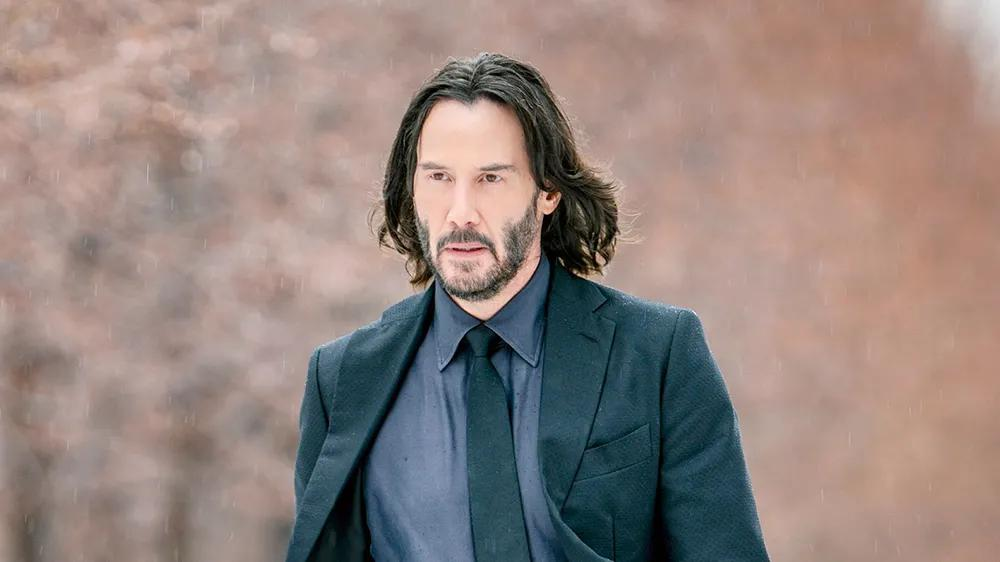

In [105]:
query = "Who is John Wick?"
urls = get_documents(query, mode="summary", top_k=1)
show_top_images_from_urls(urls)


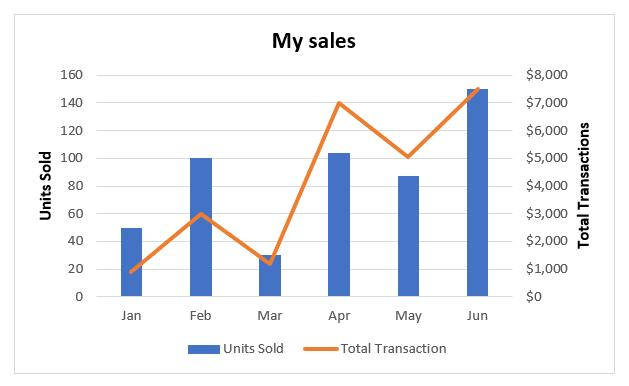

In [107]:
query = "What is sale statistics in the last year?"
urls = get_documents(query, mode="summary", top_k=1)
show_top_images_from_urls(urls)


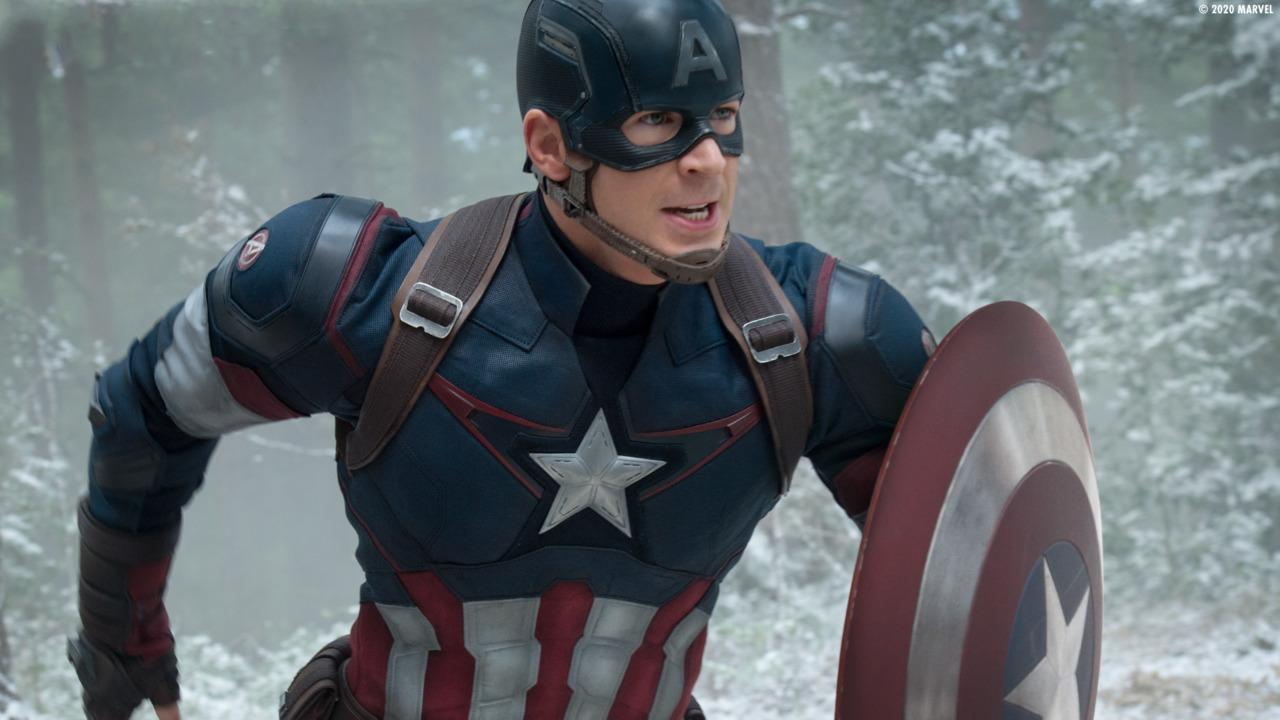
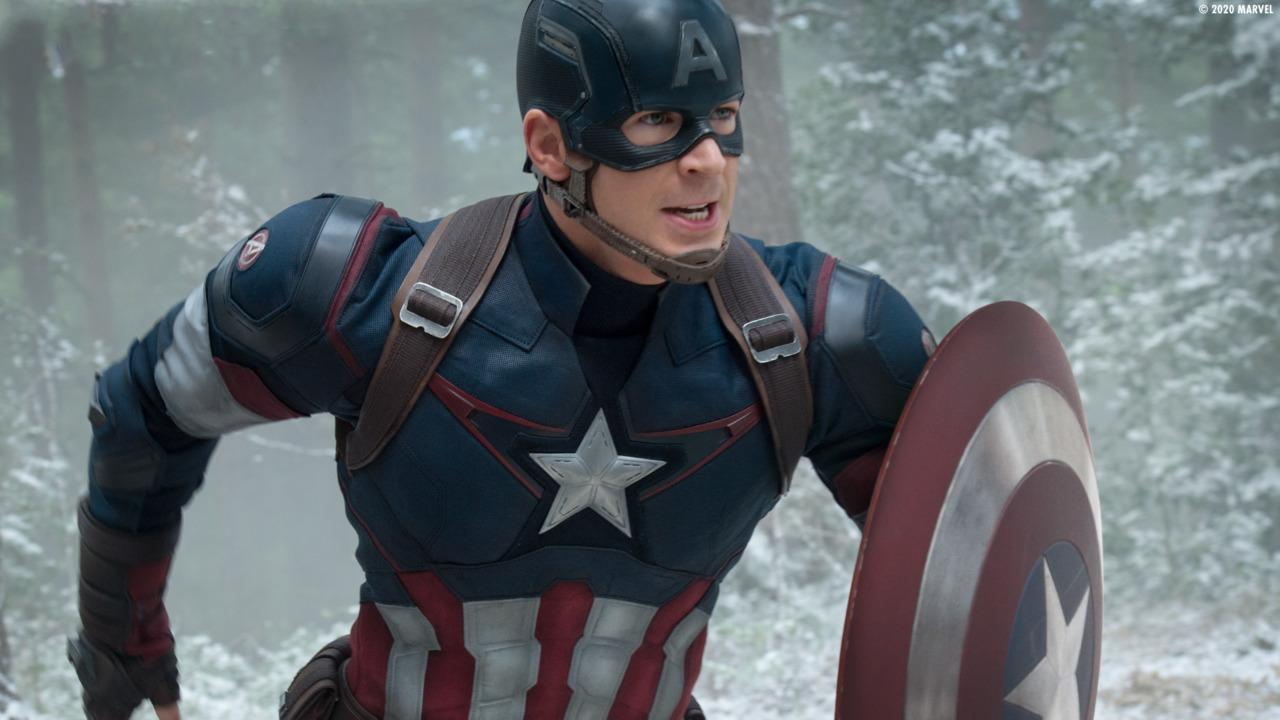
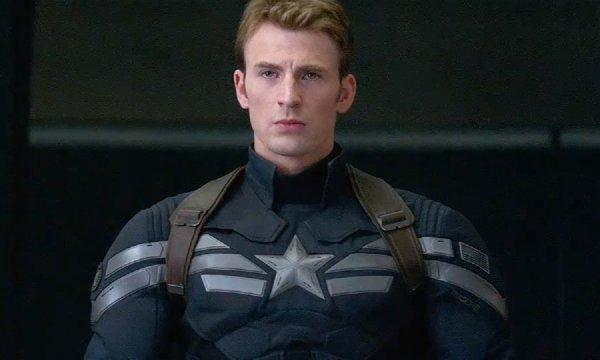

In [109]:
query = "Who is captain America?"
urls = get_documents(query, mode="summary", top_k=3)
show_top_images_from_urls(urls)


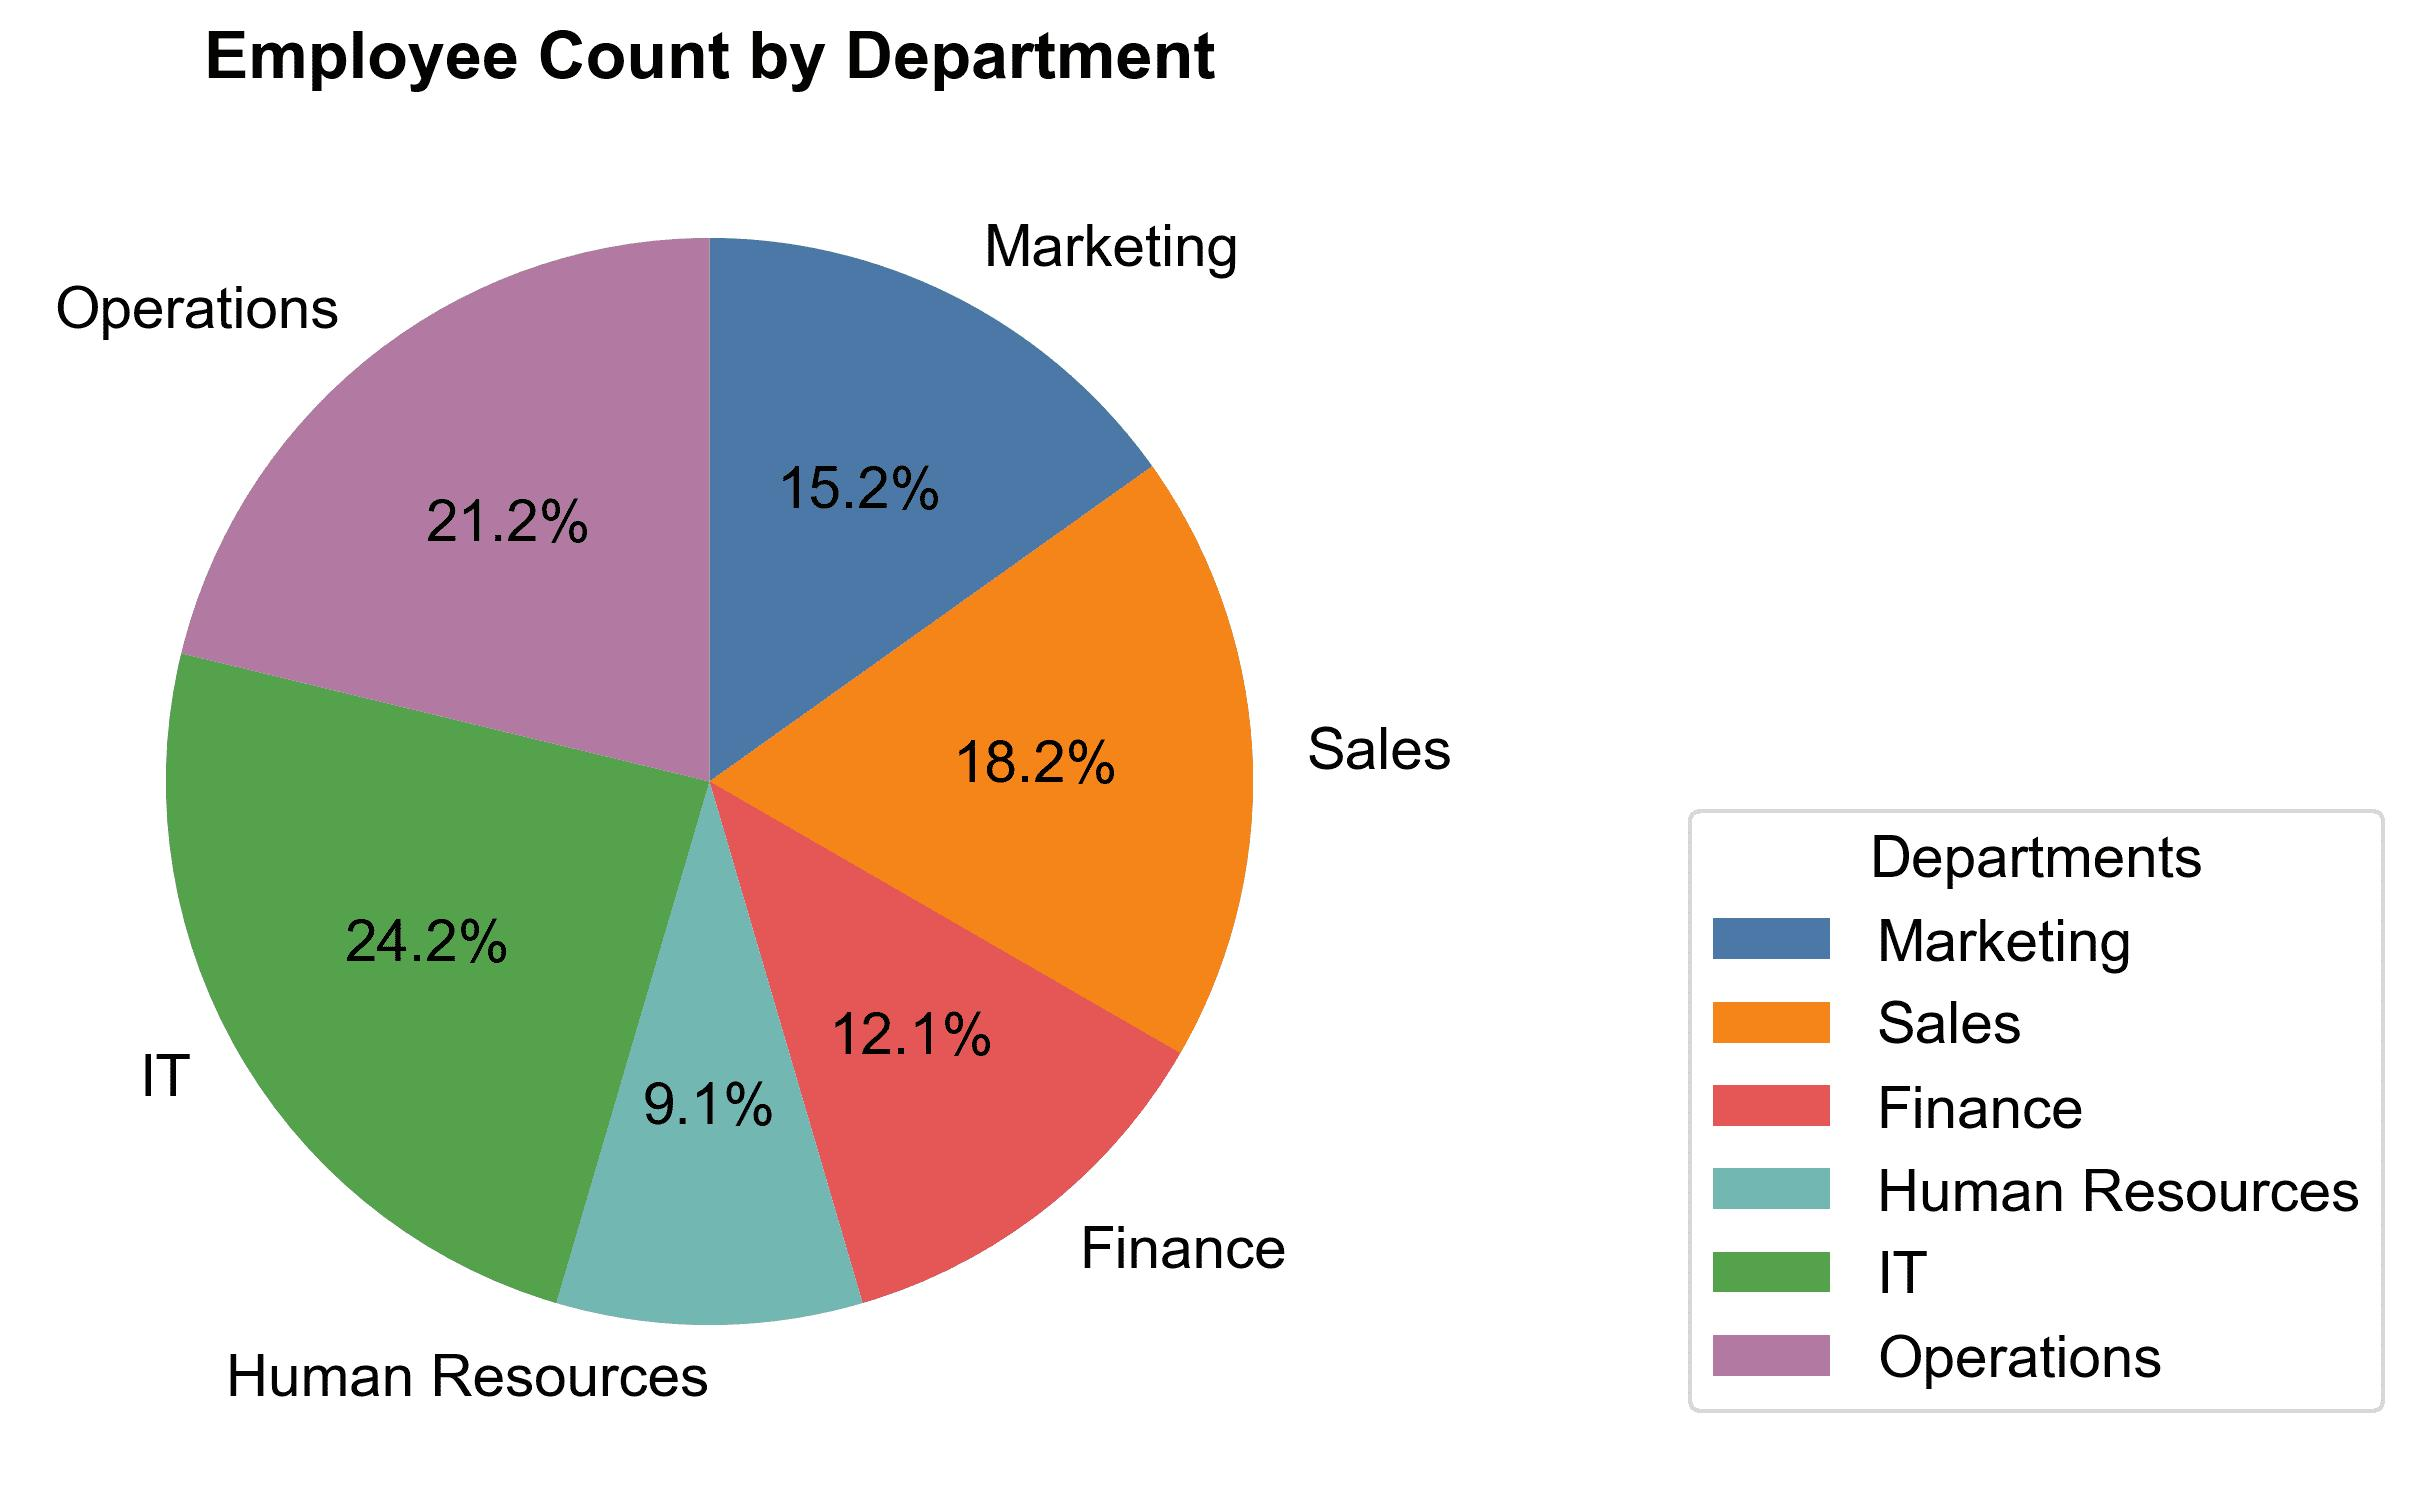
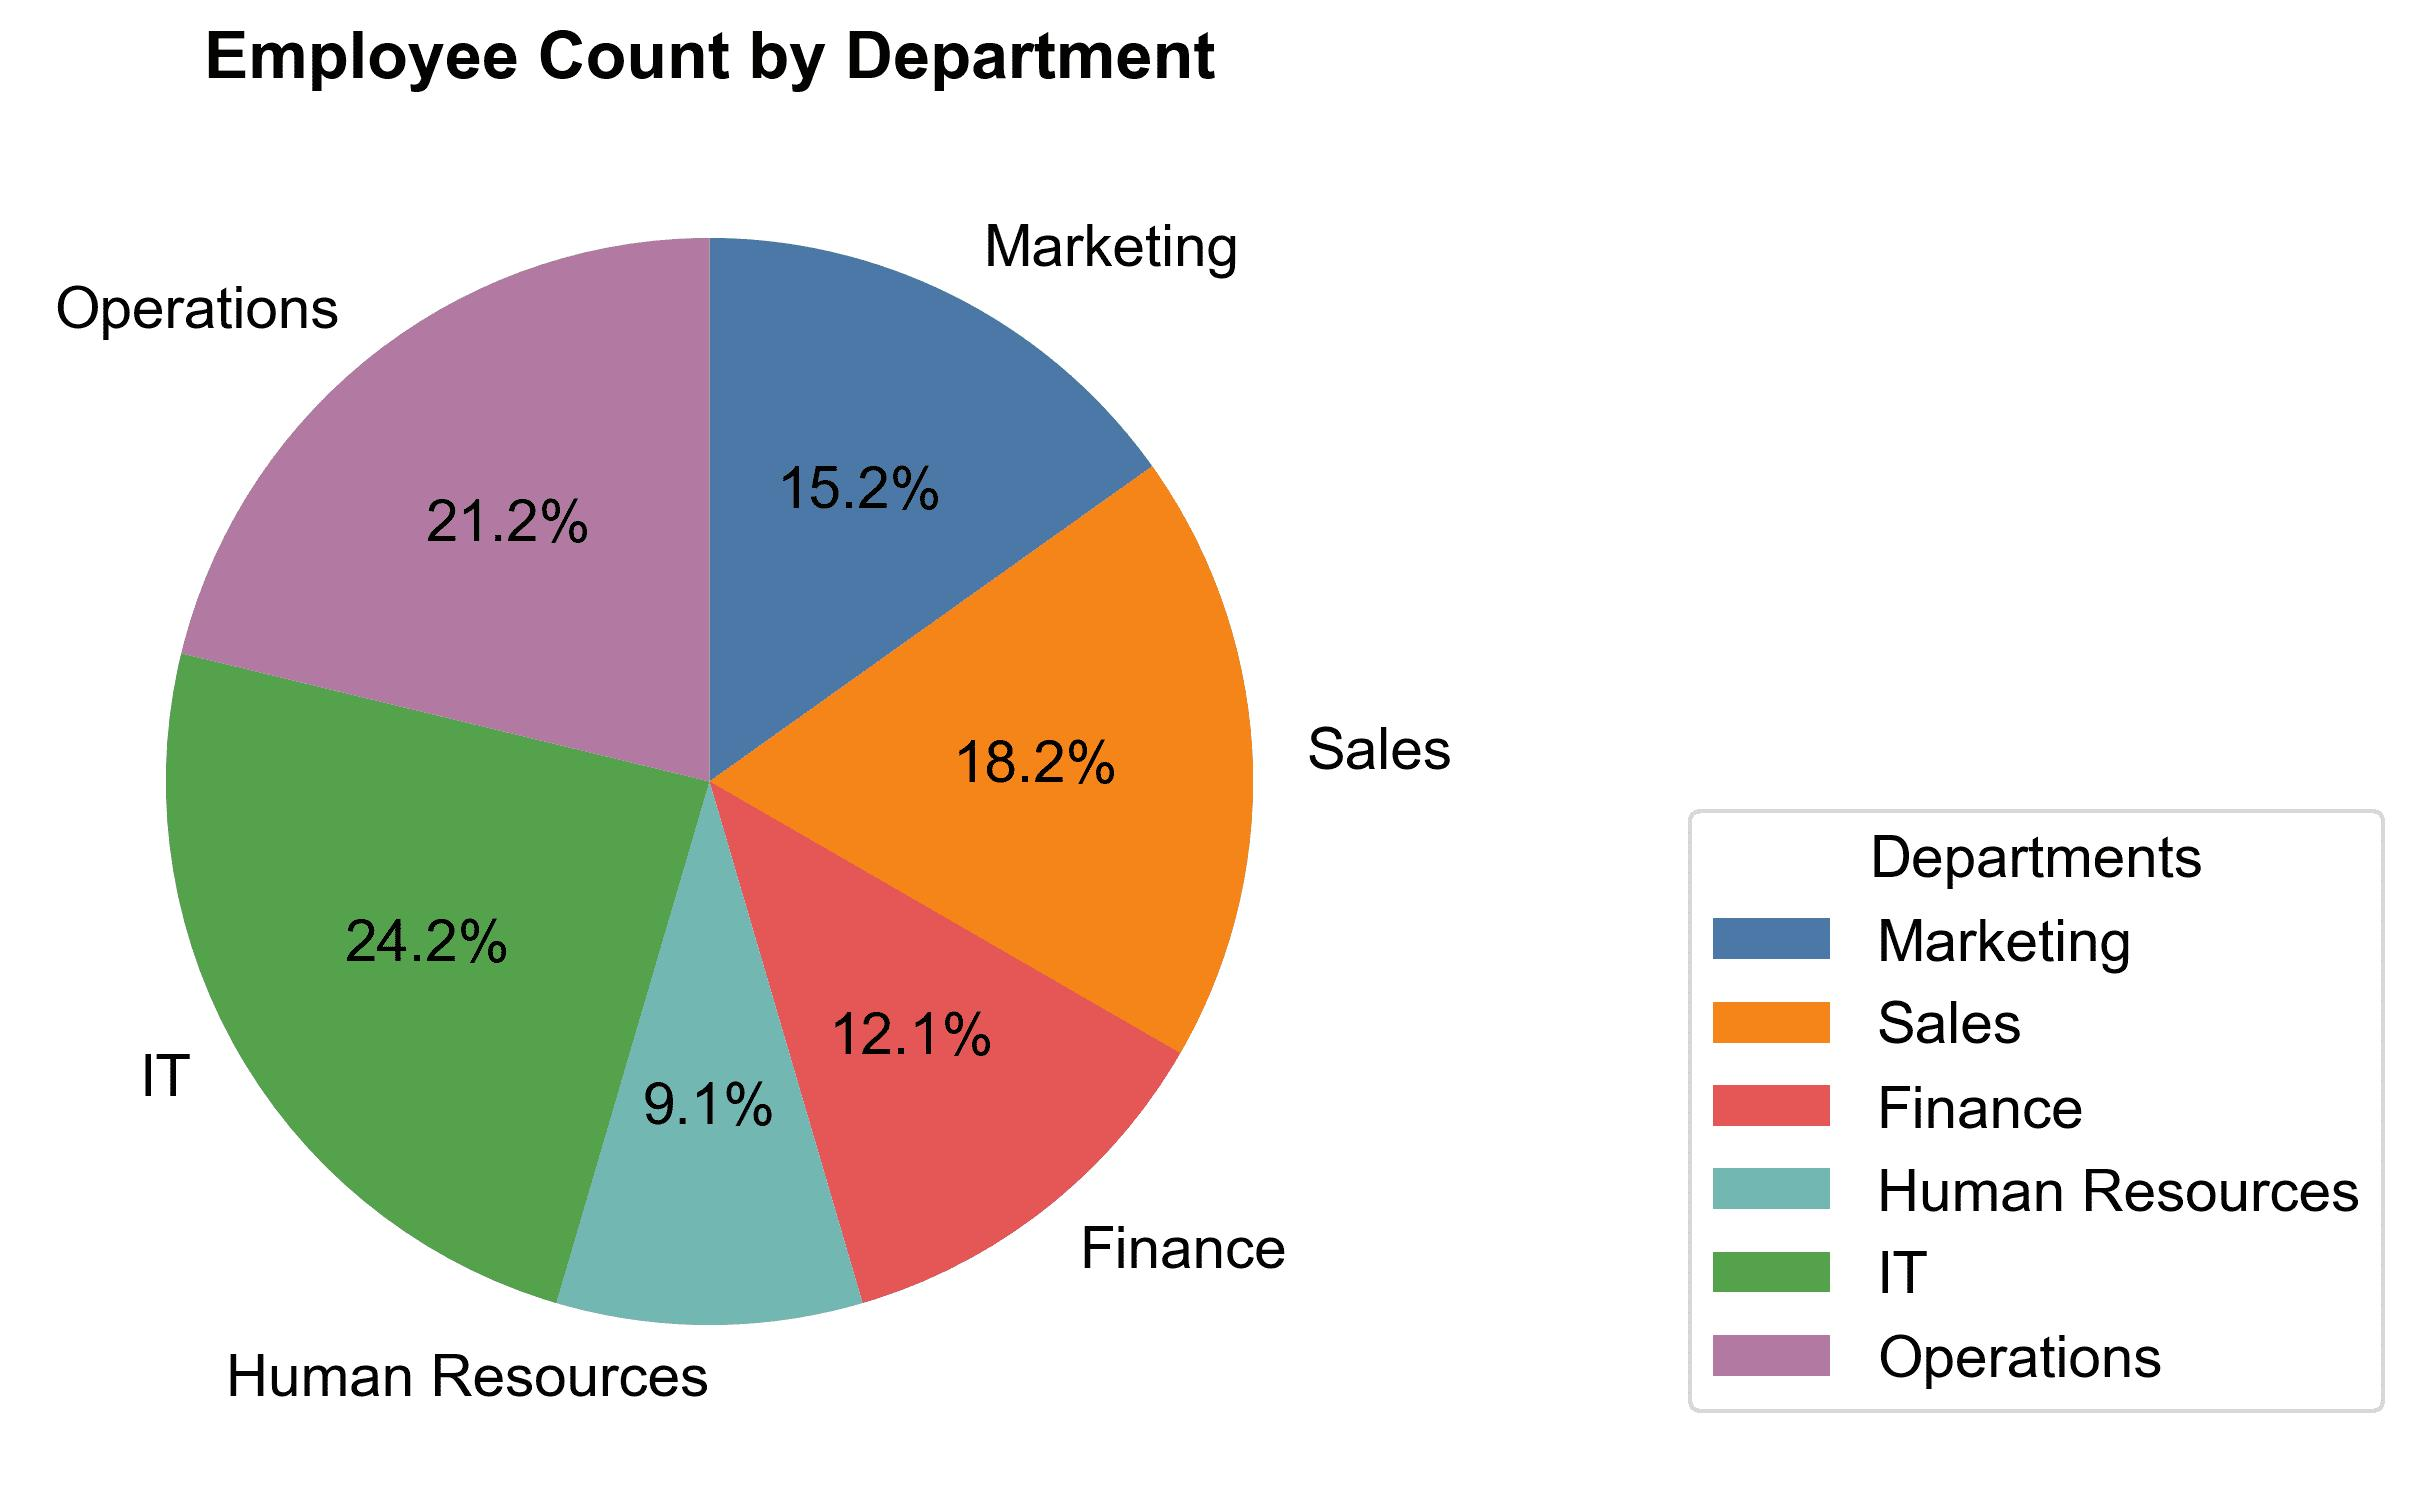
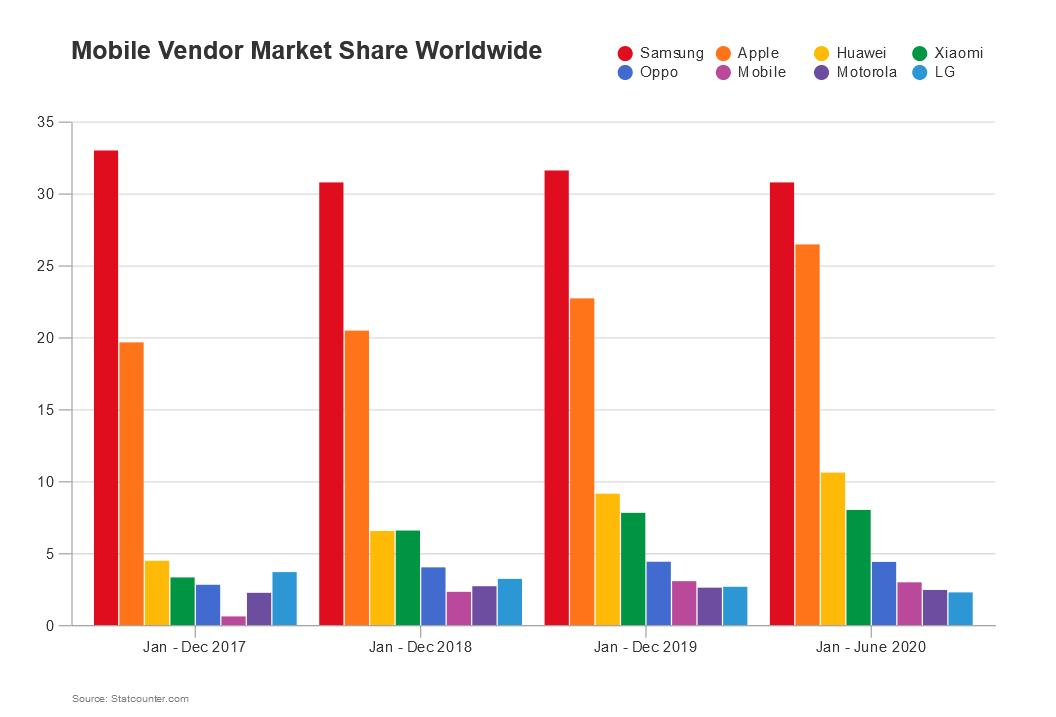

In [111]:
query = "Which department has the highest proportion of employees, and what is that percentage?"
urls = get_documents(query, mode="summary", top_k=3)
show_top_images_from_urls(urls)

VLM inference


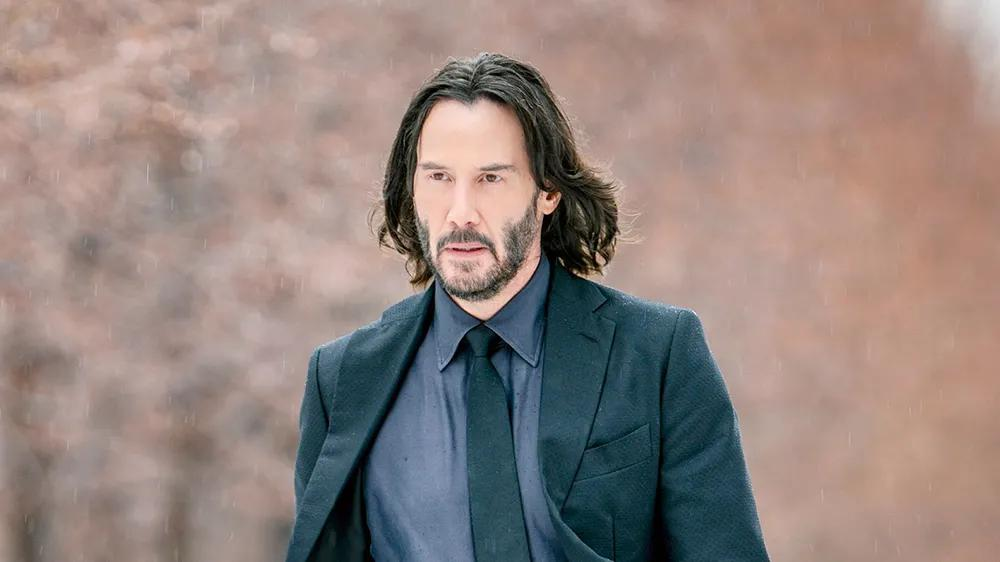

In [106]:
query = "Who is John Wick?"
urls = get_documents(query, mode="vlm", top_k=1)
show_top_images_from_urls(urls)


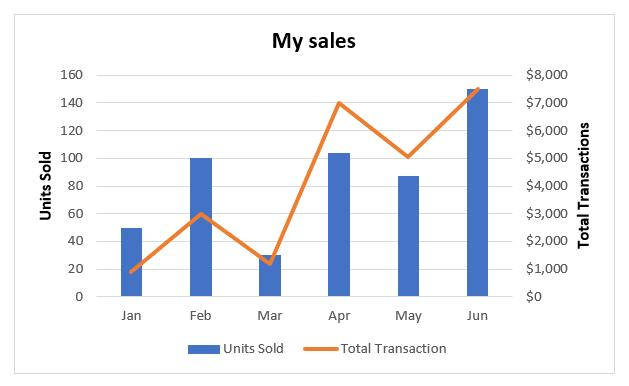

In [108]:
query = "What is sale statistics in the last year?"
urls = get_documents(query, mode="vlm", top_k=1)
show_top_images_from_urls(urls)


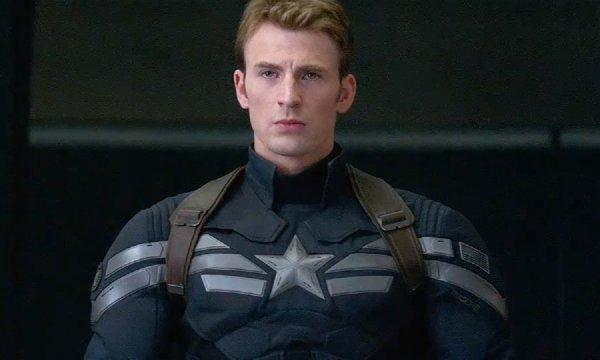
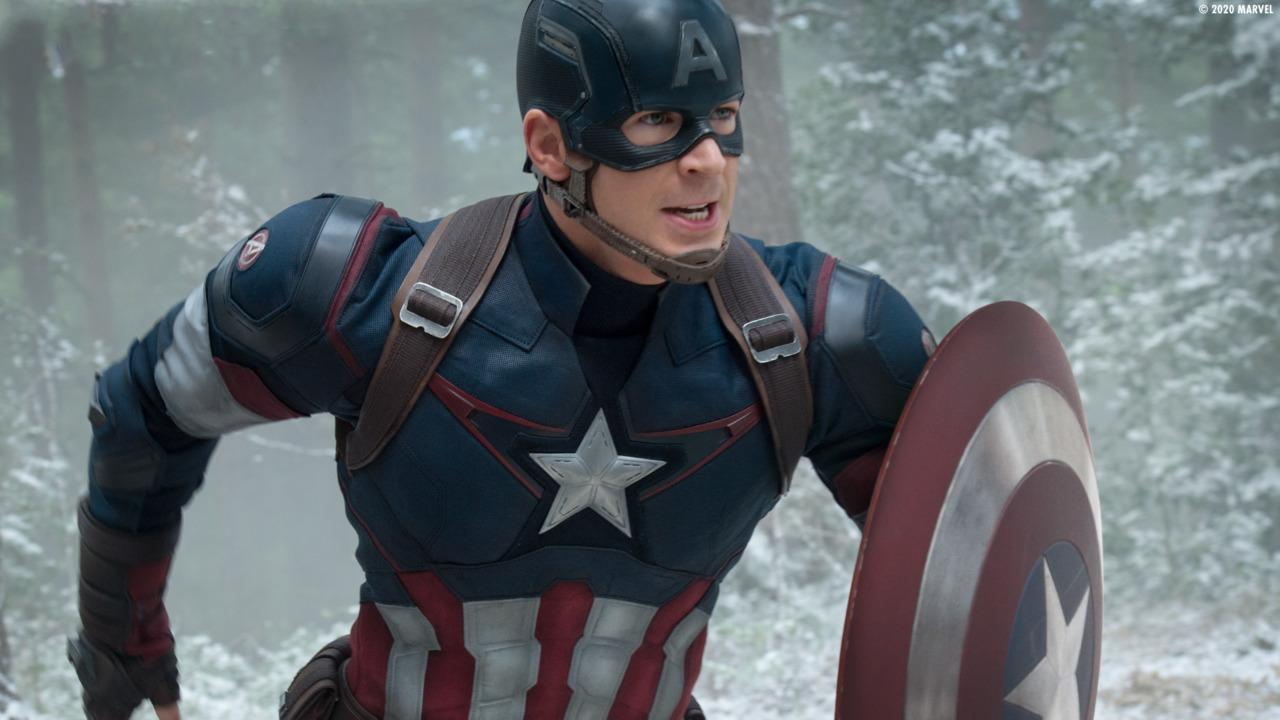
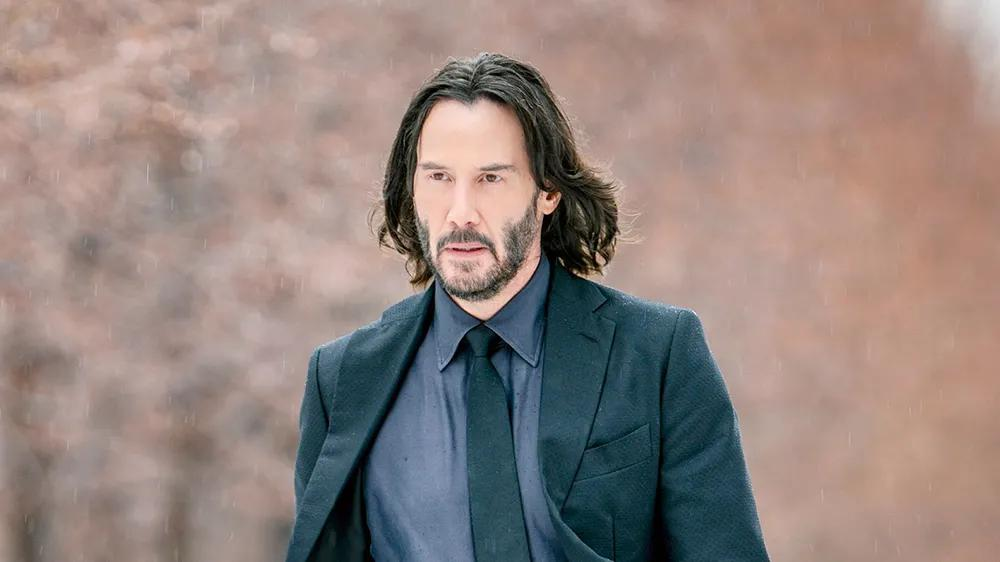

In [110]:
query = "Who is captain America?"
urls = get_documents(query, mode="vlm", top_k=3)
show_top_images_from_urls(urls)


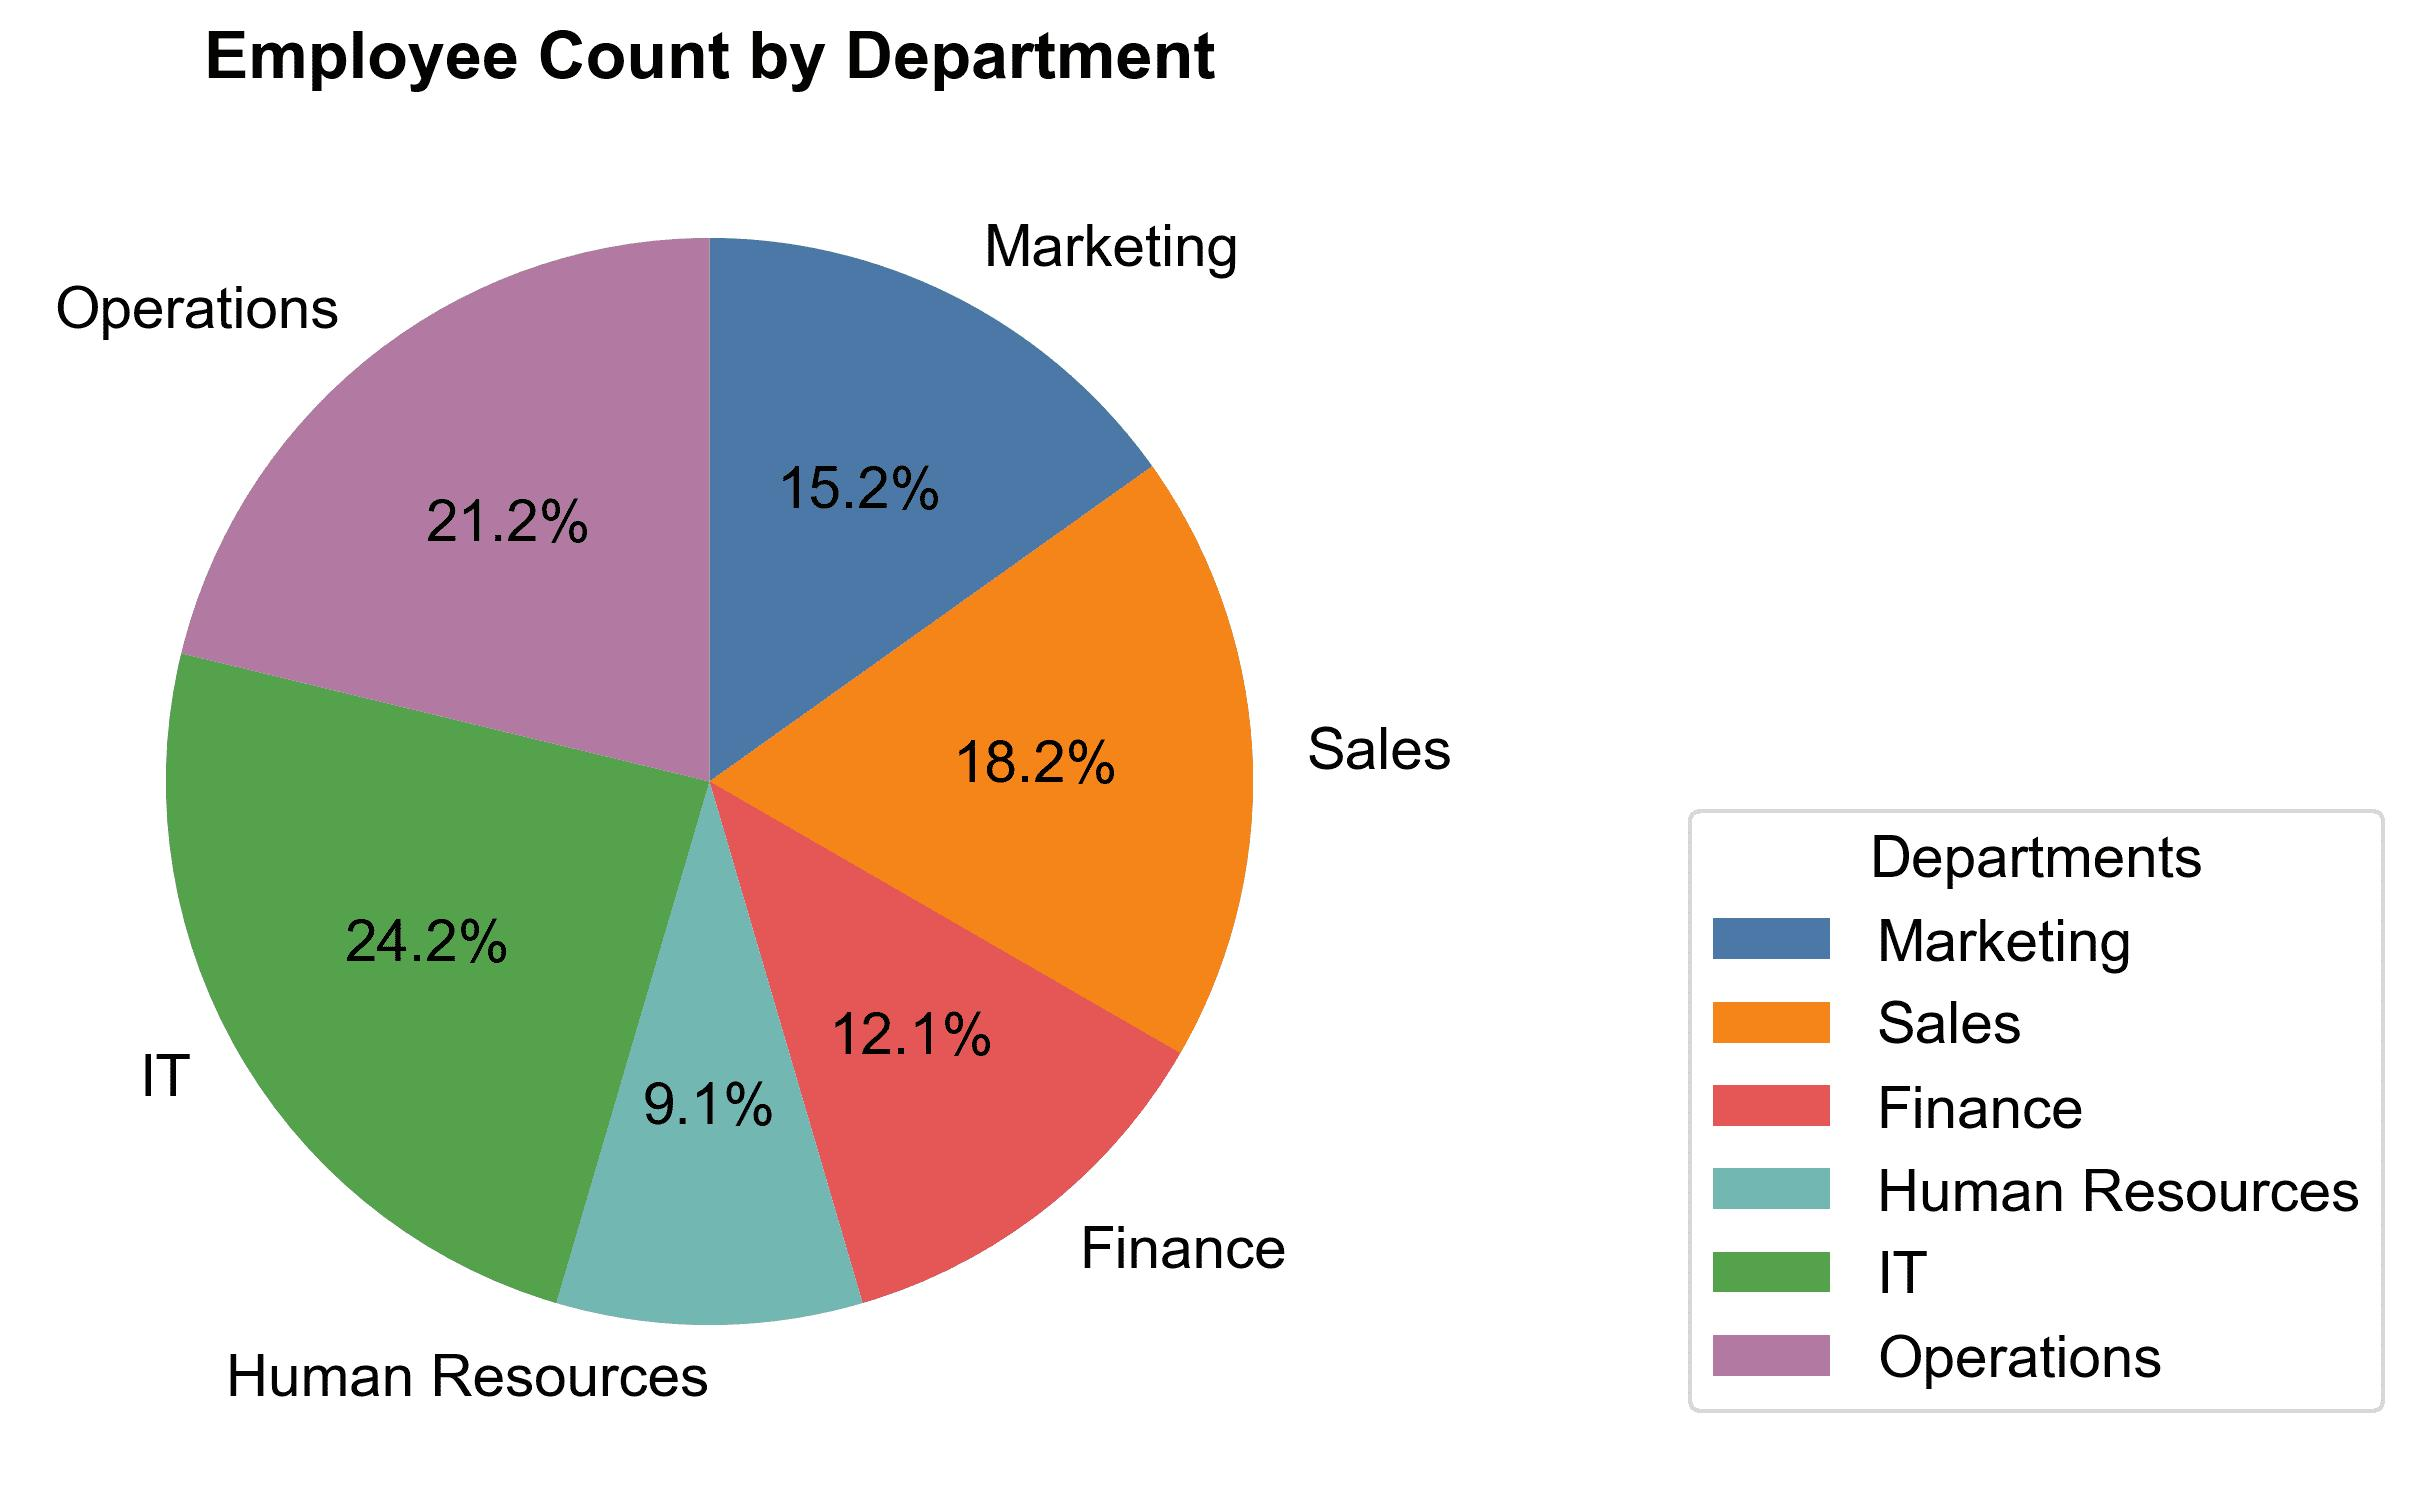
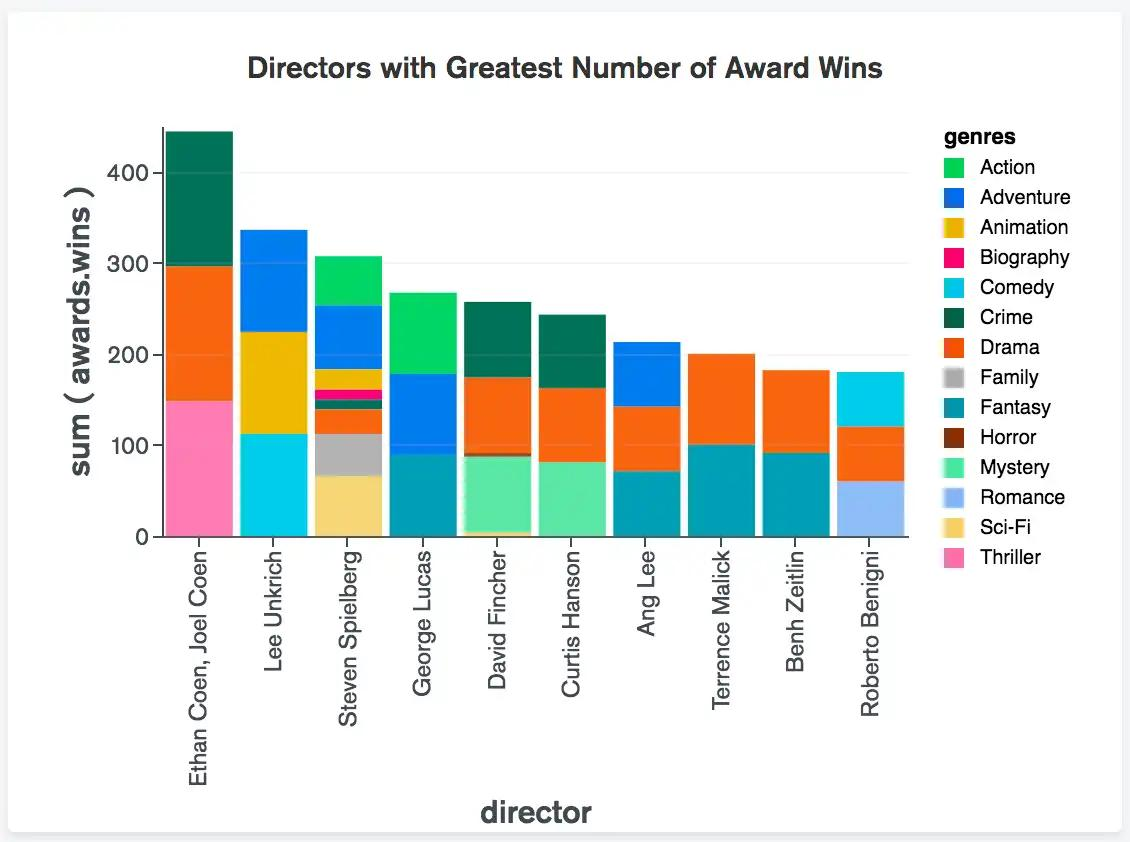
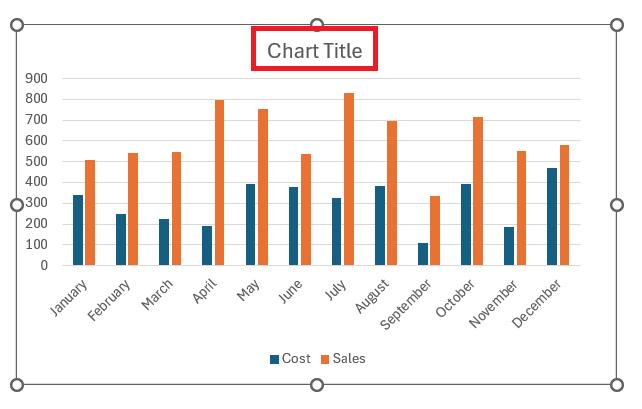

In [112]:
query = "Which department has the highest proportion of employees, and what is that percentage?"
urls = get_documents(query, mode="vlm", top_k=3)
show_top_images_from_urls(urls)